# Estudo analítico de performance de campanhas de um Shopping Center

Este projeto de estudo tem como finalidade analisar, dentro de um período de 5 meses durante o ano de 2021, como grupos de campanhas de um Shopping Center perfomaram no trafégo pago.

Para este projeto, utilizei uma base disponibilizada na plataforma Kaggle (https://www.kaggle.com/datasets/marceaxl82/shopping-mall-paid-search-campaign-dataset/data).

Ela contém informações sobre os grupos de anúncio, clicks, conversões, impressões, faturamento e custo.

# Importações

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Importação da base de dados

In [2]:
df = pd.read_csv('final_shop_6modata.csv', sep=',')
df.head()

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Conv Rate,Cost,CPC,Revenue,Sale Amount,P&L
0,Shop - 1:1 - Desk - [shop coupon code],July,16038,6504,0.41,1166,0.10,6669,1.03,6402,136770.05,-267.086
1,Shop - 1:1 - Desk - [shop coupon],July,36462,14367,0.39,2188,0.09,13746,0.96,13262,283215.21,-483.951
2,Shop - 1:1 - Desk - [shop discount code],July,3635,1458,0.40,248,0.09,1606,1.10,1723,39165.46,117.136
3,Shop - 1:1 - Desk - [shop promo code],July,26185,10418,0.40,2294,0.12,13278,1.27,13042,284823.48,-235.921
4,Shop - 1:1 - Desk - [shop promo],July,808,282,0.35,61,0.15,391,1.39,337,7717.77,-53.604


In [3]:
df.tail()

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Conv Rate,Cost,CPC,Revenue,Sale Amount,P&L
185,Shop - Exact - Desk - Black Friday/Cyber Monday,November,257,24,0.09,7,0.28,3,0.14,45,898.80,41.946
186,Shop - 1:1 - Desk - [shop discount code],November,7254,2725,0.38,512,0.11,3182,1.17,3227,66672.29,45.468
187,Shop - Exact - Desk - Coupon Code,November,18526,5553,0.30,919,0.10,5982,1.08,6047,129556.90,64.552
188,Shop - Exact - Mob - Black Friday/Cyber Monday,November,3662,266,0.07,24,0.09,44,0.17,160,3268.63,115.963
189,Shop - Exact - Desk - Promo Code,November,25592,7726,0.30,1731,0.14,10914,1.41,11223,236665.59,308.975


In [4]:
df.shape
print(f'O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.')

O dataset possui 190 linhas e 12 colunas.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ad Group     190 non-null    object 
 1   Month        190 non-null    object 
 2   Impressions  190 non-null    int64  
 3   Clicks       190 non-null    int64  
 4   CTR          190 non-null    float64
 5   Conversions  190 non-null    int64  
 6   Conv Rate    190 non-null    float64
 7   Cost         190 non-null    int64  
 8   CPC          190 non-null    float64
 9   Revenue      190 non-null    int64  
 10  Sale Amount  190 non-null    float64
 11  P&L          190 non-null    float64
dtypes: float64(5), int64(5), object(2)
memory usage: 17.9+ KB


In [6]:
df.isnull().sum()

Ad Group       0
Month          0
Impressions    0
Clicks         0
CTR            0
Conversions    0
Conv Rate      0
Cost           0
CPC            0
Revenue        0
Sale Amount    0
P&L            0
dtype: int64

# Feature Engineering

### Foram definidas funções para extrair informações dos 'Ad Group':

- Tipo de disposivo: onde cada grupo de anúncio foi veiculado
- Tipo de correspondência: como a plataforma de anúncio relaciona a keyword com a busca do usuário
- Tipo de keyword: o que aciona o anúncio

In [7]:
def extract_device(ad_group):
    if " - Desk - " in ad_group:
        return "Desk"
    elif " - Mob - " in ad_group:
        return "Mobile"
    return None

def extract_match_type(ad_group):
    if " - 1:1 - " in ad_group:
        return "1:1"
    elif " - Phrase - " in ad_group:
        return "Phrase"
    elif " - Exact - " in ad_group:
        return "Exact"
    return None

def extract_intent(ad_group):
    if "[" in ad_group and "]" in ad_group:
        return ad_group.split("[")[1].split("]")[0]

    # Caso padrão (último bloco)
    return ad_group.split(" - ")[-1]

### Criação de novas colunas

- device_type: divide as campanhas por dispositivo veiculado (Desk/Mob)
- intent: divide as campanhas por tipo de keyword
- match_type: divide as campanhas por tipo de correspondência
- cpa: custo por aquisição
- roas: retorno a cada $1 investido
- ticket: valor médio gasto em cada compra
- roi: retorno sobre o investimento
- taxa_conversão: anteriormente o dataset veio com uma coluna Conv Rate, porém verifiquei que os valores estavam incorretos, por isso, foi criada uma nova coluna para o cálculo da taxa de conversão.
- conv_imp: conversão por impressão, avalia o público para o qual a campanha está sendo mostrada
- revenue_vs_cpa: cruza quando se paga para gerar uma conversão e quanto se recebe por cada conversão


In [8]:
df['device_type'] = df['Ad Group'].apply(extract_device)
df['intent'] = df['Ad Group'].apply(extract_intent)
df['match_type'] = df['Ad Group'].apply(extract_match_type)

df['cpa'] = np.round(np.where(df['Conversions'] == 0, 0, df['Cost'] / df['Conversions']),2)
df['roas'] = np.round(np.where(df['Cost'] == 0, 0, df['Revenue'] / df['Cost']),2)
df['ticket'] = np.round(np.where(df['Conversions'] == 0, 0, df['Sale Amount'] / df['Conversions']),2)

df['roi'] = np.round(np.where(df['Cost'] == 0, 0, ((df['Revenue'] - df['Cost']) / df['Cost']) * 100),2)
df['taxa_conversao'] = np.where(df['Clicks'] == 0, 0, round((df['Conversions'] / df['Clicks']),2))
df['revenue_vs_cpa'] = np.round(np.where(df['Conversions'] == 0, 0, (df['Revenue'] - df['Cost']) / df['Conversions']),2)

#Coluna de cpi, é a taxa de conversão por impressão, para ver se o anúncio é relevante para o público
df['conv_imp'] = np.where(df['Impressions'] == 0, 0, round((df['Conversions'] / df['Impressions']),2))

#Validei que a coluna Conv Rate estava errada, então criei a coluna taxa_conversao para ter a taxa de conversão correta. 
df.drop(columns=['Conv Rate'], inplace=True)


In [9]:
# Ajuste da coluna Month
month_order = ['July', 'August', 'September', 'October', 'November']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Ajuste da coluna P&L
df['P&L'] = np.round(df['P&L'], 2)

# Exploração

## Análise estatística das variáveis

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Ad Group        190 non-null    object  
 1   Month           190 non-null    category
 2   Impressions     190 non-null    int64   
 3   Clicks          190 non-null    int64   
 4   CTR             190 non-null    float64 
 5   Conversions     190 non-null    int64   
 6   Cost            190 non-null    int64   
 7   CPC             190 non-null    float64 
 8   Revenue         190 non-null    int64   
 9   Sale Amount     190 non-null    float64 
 10  P&L             190 non-null    float64 
 11  device_type     190 non-null    object  
 12  intent          190 non-null    object  
 13  match_type      190 non-null    object  
 14  cpa             190 non-null    float64 
 15  roas            190 non-null    float64 
 16  ticket          190 non-null    float64 
 17  roi             

In [11]:
# Analisar quantas campanhas temos por mês e tipo de dispositivo
colunas = ['Month','device_type']

for i in colunas:
    print('------------')
    print(df[i].value_counts().sort_index())

------------
Month
July         38
August       38
September    38
October      37
November     39
Name: count, dtype: int64
------------
device_type
Desk      94
Mobile    96
Name: count, dtype: int64


In [12]:
df.isnull().sum()

Ad Group          0
Month             0
Impressions       0
Clicks            0
CTR               0
Conversions       0
Cost              0
CPC               0
Revenue           0
Sale Amount       0
P&L               0
device_type       0
intent            0
match_type        0
cpa               0
roas              0
ticket            0
roi               0
taxa_conversao    0
revenue_vs_cpa    0
conv_imp          0
dtype: int64

In [13]:
df.shape
print(f'O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.')

O dataset possui 190 linhas e 21 colunas.


In [14]:
df.describe(include='number')

,Impressions,Clicks,CTR,Conversions,Cost,CPC,Revenue,Sale Amount,P&L,cpa,roas,ticket,roi,taxa_conversao,revenue_vs_cpa,conv_imp
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,14077.363158,4865.805263,0.272105,505.242105,3344.063158,0.791263,2957.684211,63416.180579,-386.361895,7.638053,1.032158,129.229211,3.220579,0.113000,-1.740421,0.032105
std,29771.686227,11348.529219,0.107894,1052.202922,6524.606753,0.403312,5962.413097,125414.656922,903.073689,4.661678,1.830336,60.397362,183.034842,0.066444,4.751363,0.023020
min,35.000000,2.000000,0.050000,0.000000,1.000000,0.140000,0.000000,0.000000,-5672.270000,0.000000,0.000000,0.000000,-100.000000,0.000000,-35.000000,0.000000
25%,1065.000000,264.500000,0.192500,24.000000,188.500000,0.480000,144.500000,2985.135000,-294.972500,6.187500,0.662500,116.067500,-34.080000,0.060000,-2.475000,0.012500
50%,4969.000000,930.000000,0.285000,70.500000,563.500000,0.635000,459.500000,10274.105000,-75.975000,7.155000,0.850000,130.485000,-15.185000,0.100000,-0.855000,0.030000
75%,13380.000000,4190.500000,0.360000,428.250000,2967.000000,1.107500,2672.250000,59345.195000,-6.027500,8.547500,0.967500,148.012500,-3.250000,0.160000,-0.037500,0.050000
max,276568.000000,99526.000000,0.470000,7563.000000,43542.000000,2.020000,42440.000000,886095.310000,1507.680000,41.890000,20.000000,678.000000,1900.000000,0.400000,19.000000,0.090000


Insights iniciais:

- P&L: média de -386.36 e mediana de - 76, ou seja, a maior parte das campanhas gera prejuízo
- roas: média de retorno a cada $1 investido é praticamento 1:1, ou seja, há campanhas que apenas se pagam, não geram lucros
- Cost e Revenue: o valor investido é maior do que o que se ganha com o anúncio
- roi: mediana de -15,18%, ou seja, qualquer variação leva uma campanha ao prejuízo
- cpa e revenue_vs_cpa: o custo para gerar uma conversão é maior do que o que se ganha por ela

Obs: considerar mediana em P&L e roi, pois houveram outliers 


## Análise exploratória dos gráficos

### Mapa de correlação entre variáveis contínuas

<Axes: >

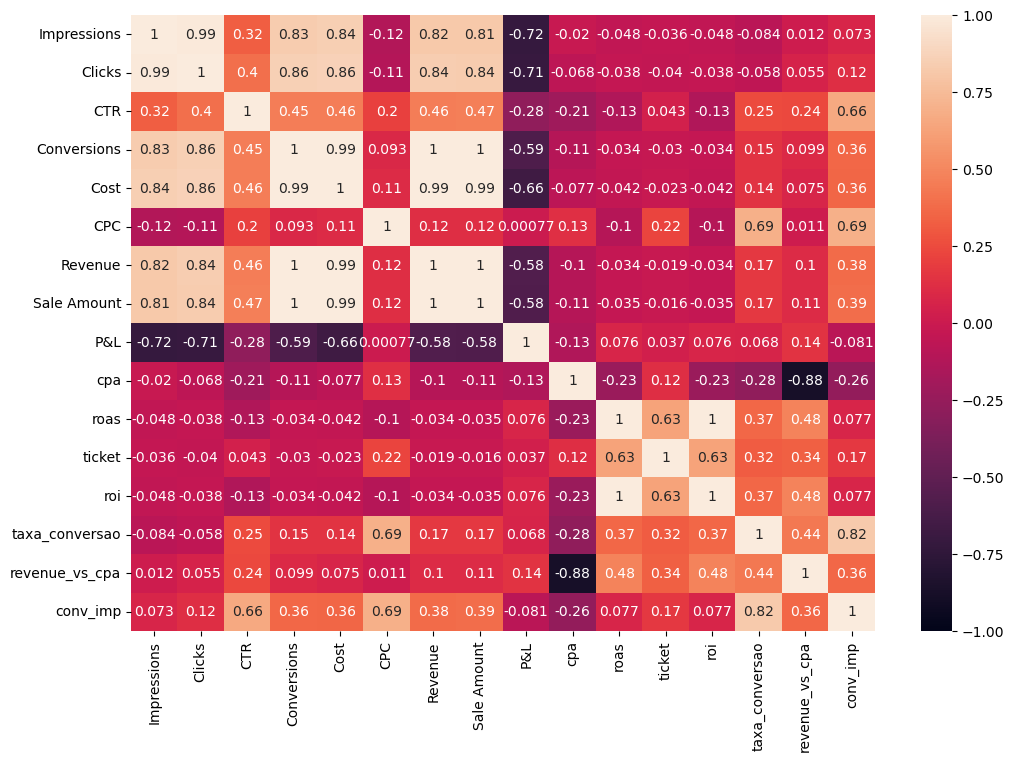

In [15]:
plt.figure(figsize=(12,8))
df_corr = df.select_dtypes(include='number')
sns.heatmap(data=df_corr.corr(), annot=True, vmin=-1, vmax=1)

- Quando impressões caem, geram prejuízo
- A correlação entre CPC e taxa_conversão é um termômetro para avaliar qualidade do anúncio
- A correlação entre conv_imp, CTR, CPC e taxa_conversao é um termômetro para avaliar público das campanhas

### Impressions x P&L

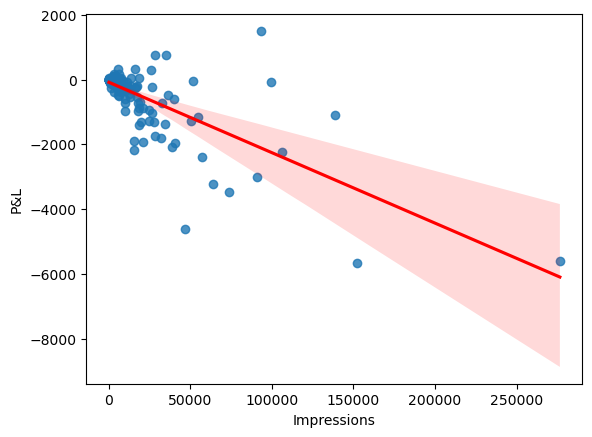

In [16]:
sns.regplot(data=df, x='Impressions', y='P&L', line_kws={'color':'red'});

### Análise do ROI por dispositivo mês a mês

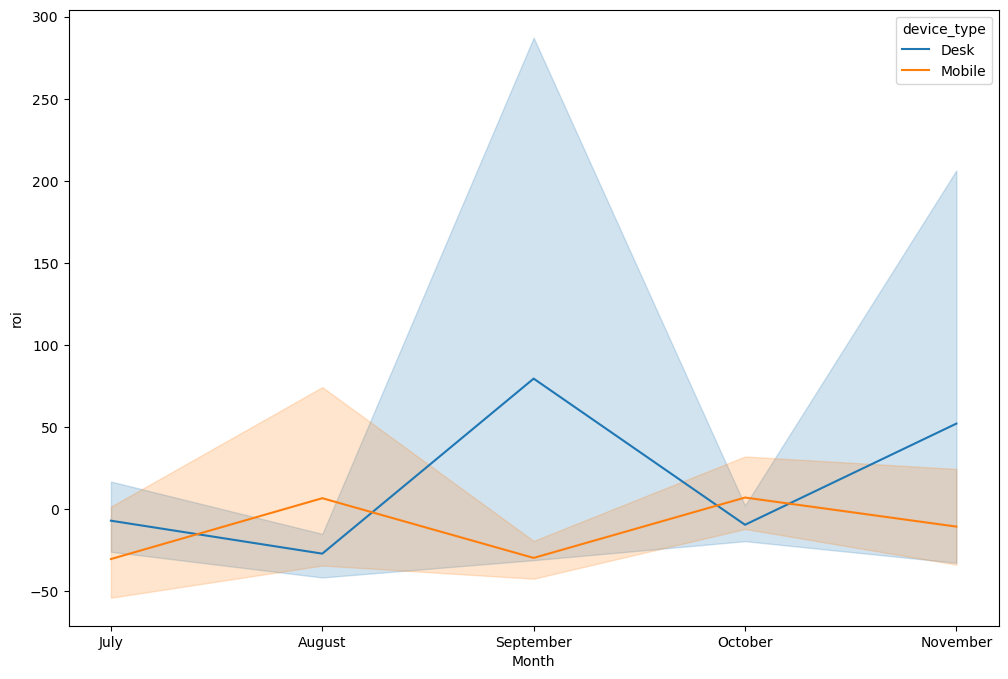

In [17]:
plt.figure(figsize=(12,8))
sns.lineplot(data=df, x='Month', y='roi', hue='device_type');

### ROI médio por keyword de busca mês a mês

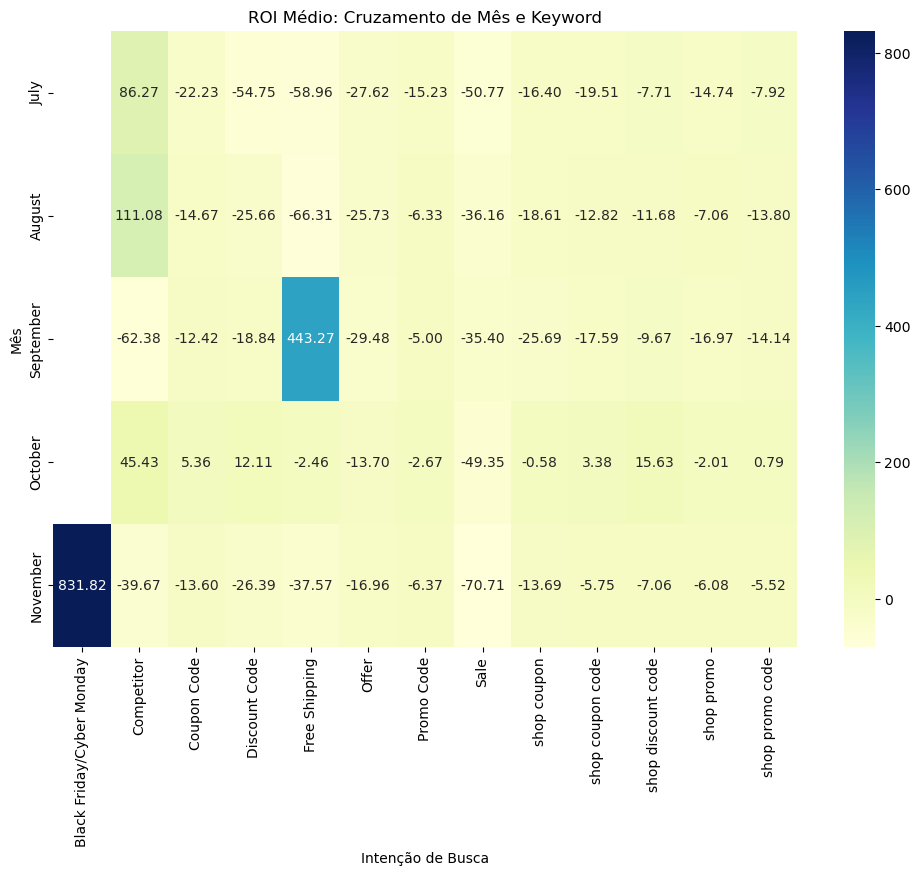

In [18]:
df_heatmap = df.groupby(['Month', 'intent']).agg(
    roi_medio=('roi', 'mean')
).reset_index()

mapa_matriz = df_heatmap.pivot(index='Month', columns='intent', values='roi_medio')

plt.figure(figsize=(12, 8))
sns.heatmap(mapa_matriz, annot=True, cmap='YlGnBu', fmt=".2f")

plt.title('ROI Médio: Cruzamento de Mês e Keyword')
plt.xlabel('Intenção de Busca')
plt.ylabel('Mês')
plt.show()

### CTR x Taxa de Conversão

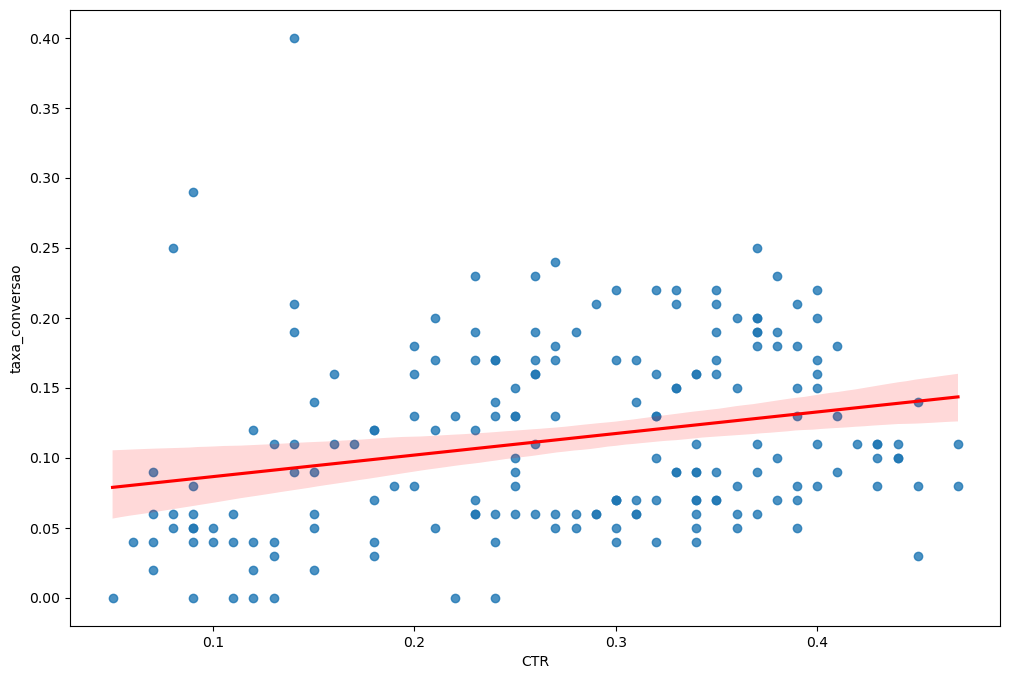

In [19]:
plt.figure(figsize=(12, 8))
sns.regplot(data=df, x='CTR', y='taxa_conversao', line_kws={'color': 'red'});

### P&L x Ad Group mês a mês

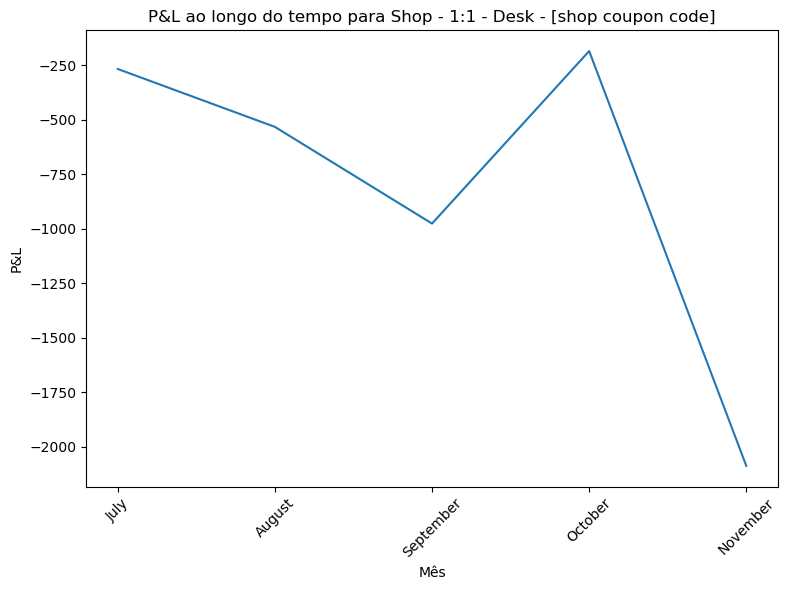

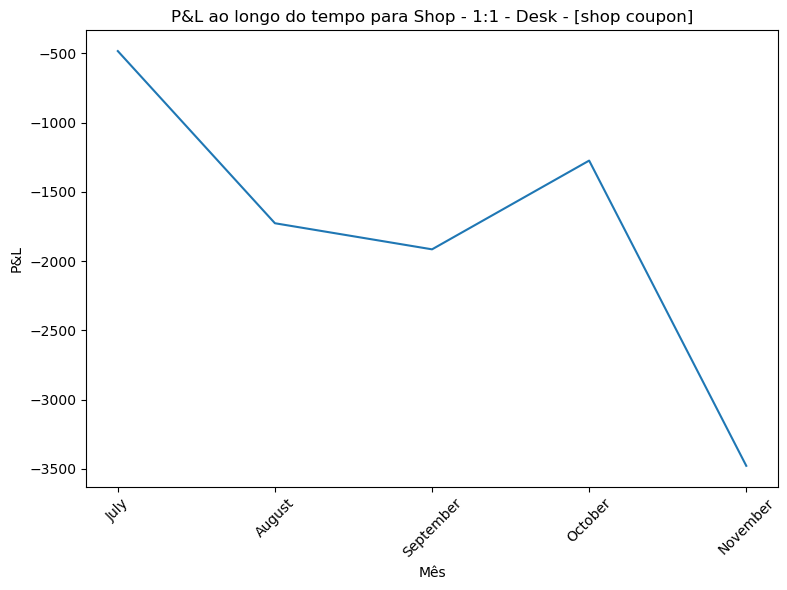

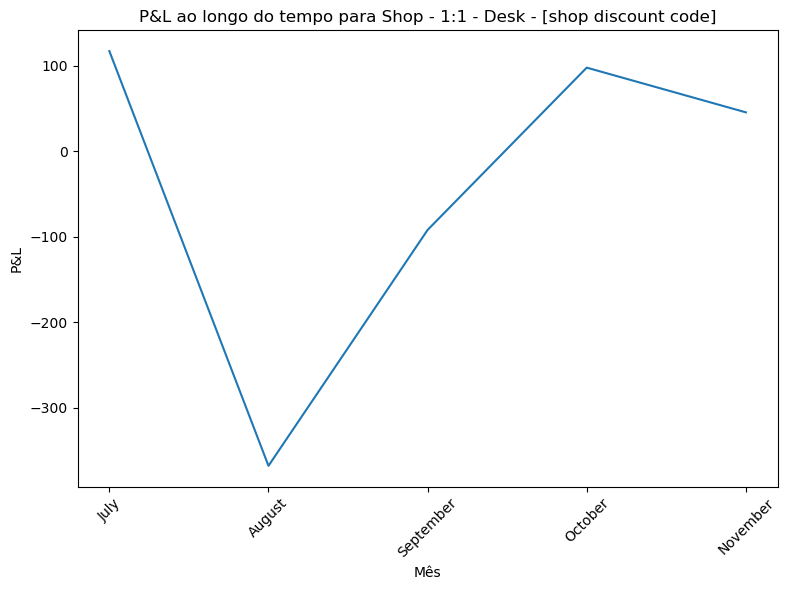

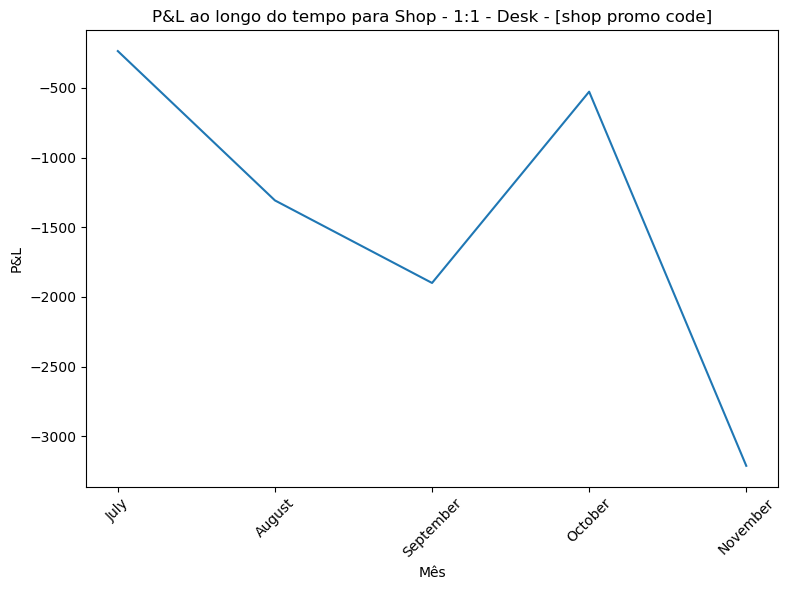

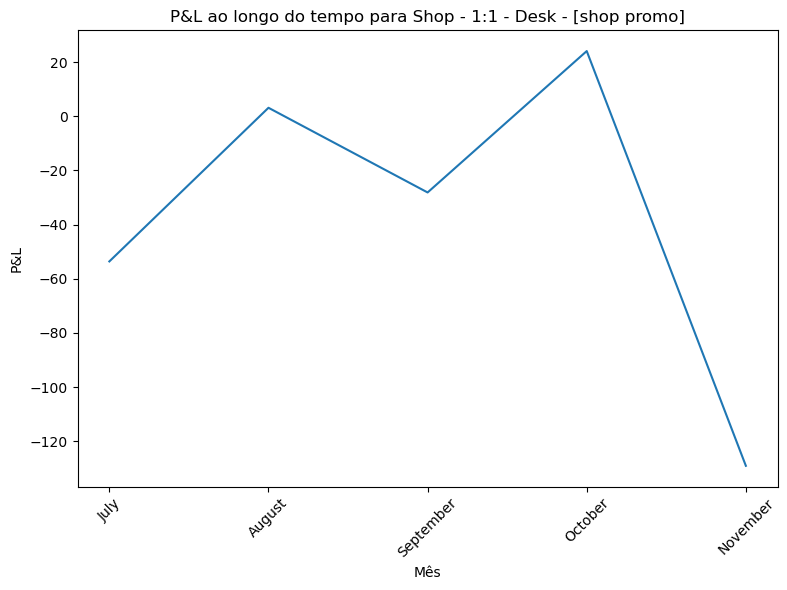

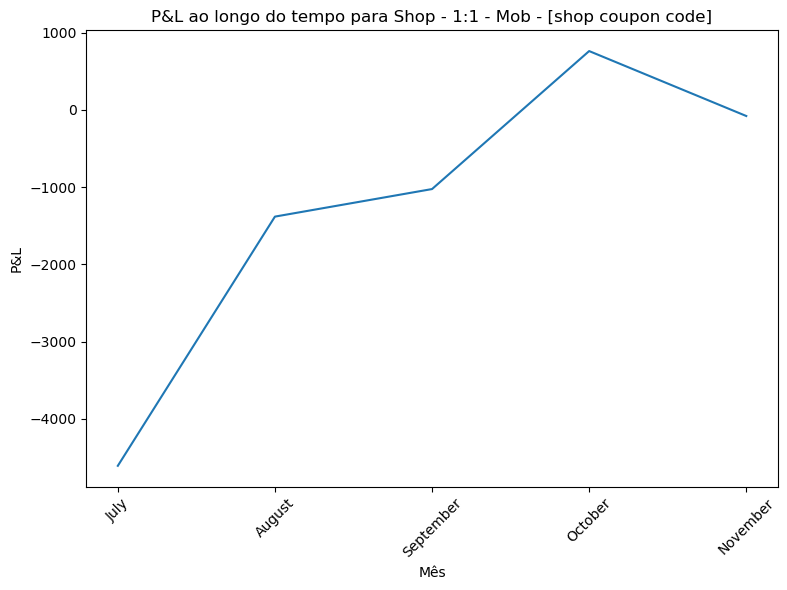

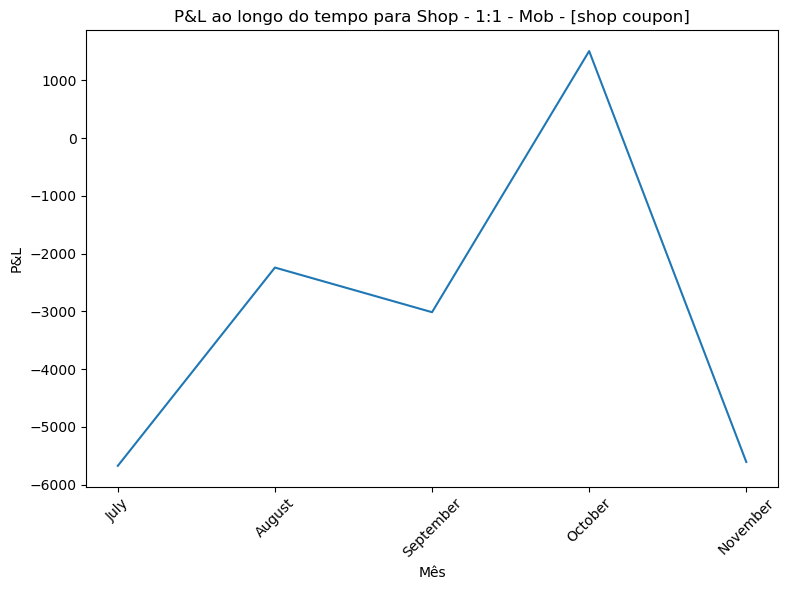

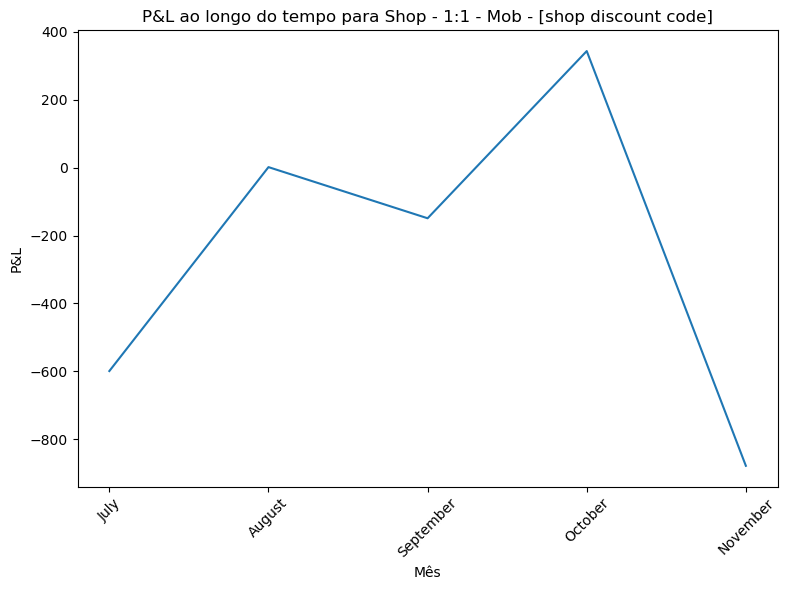

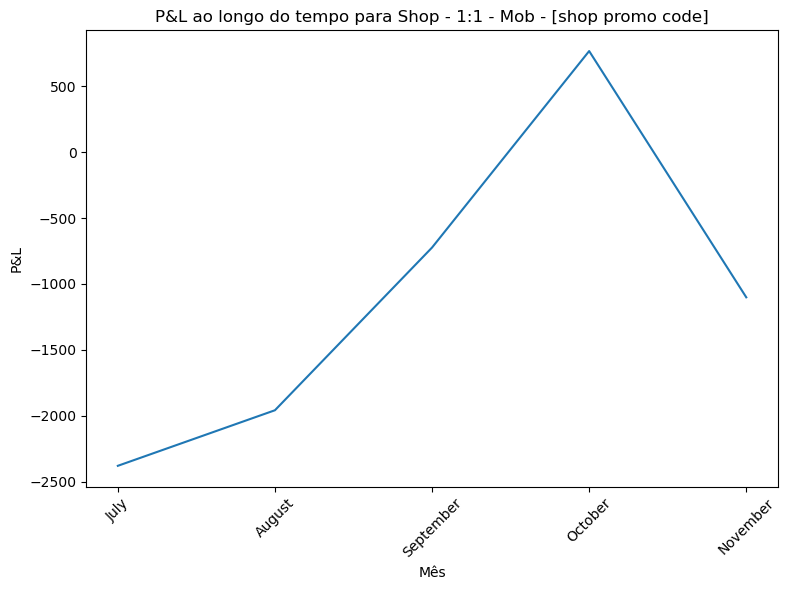

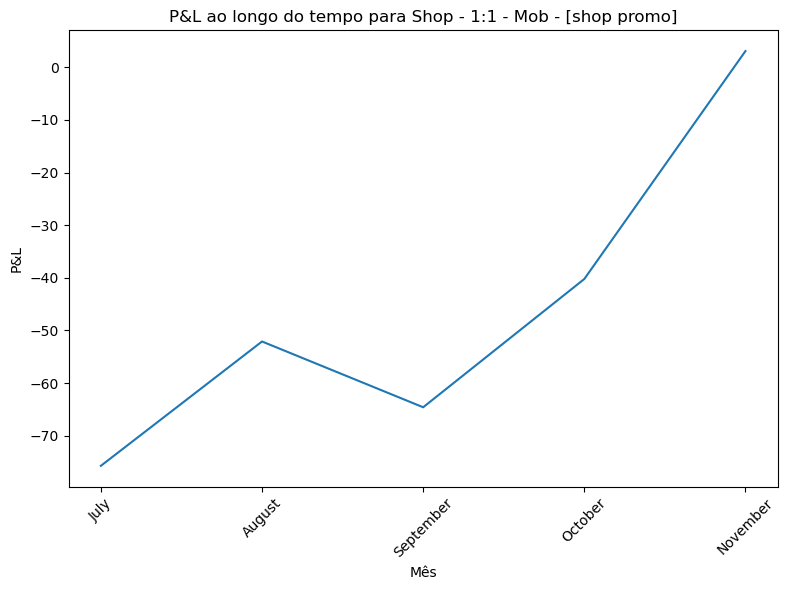

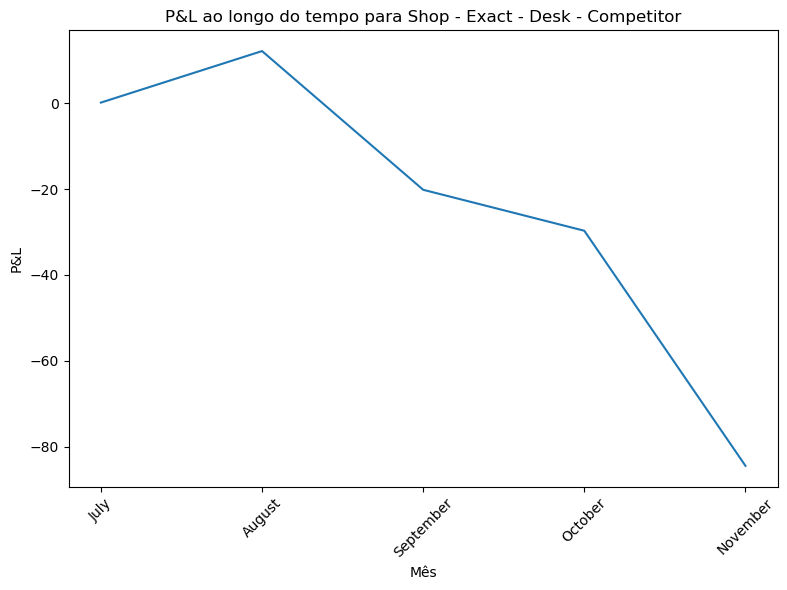

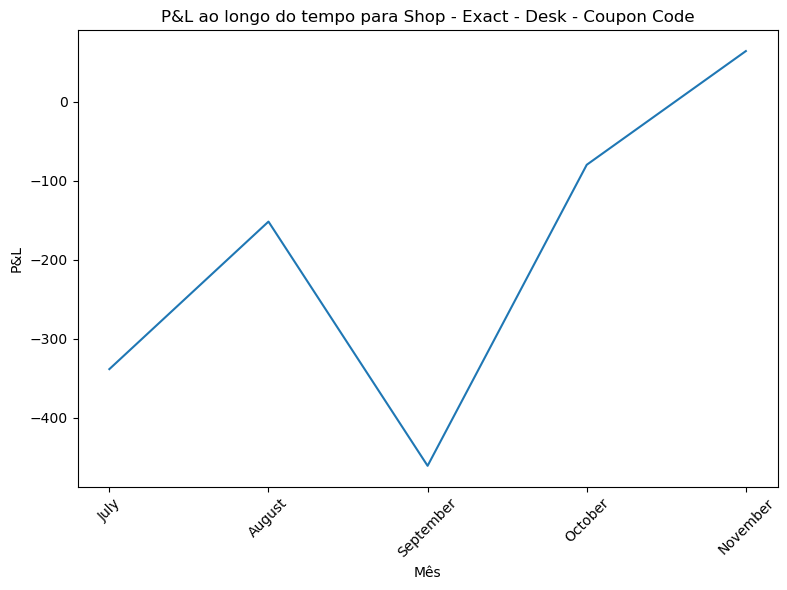

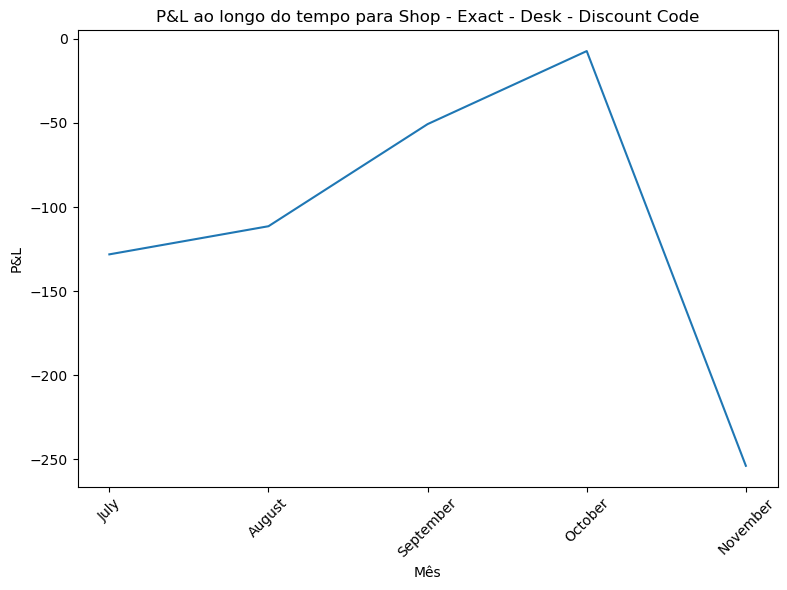

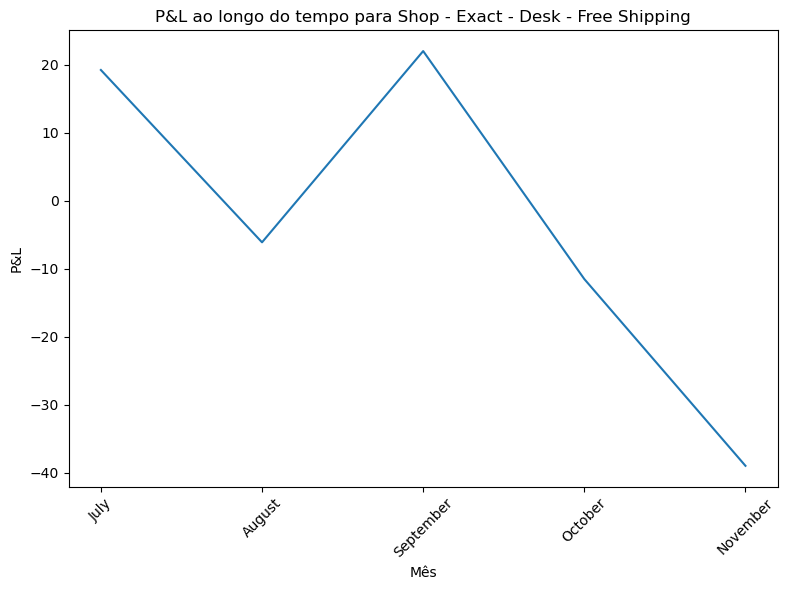

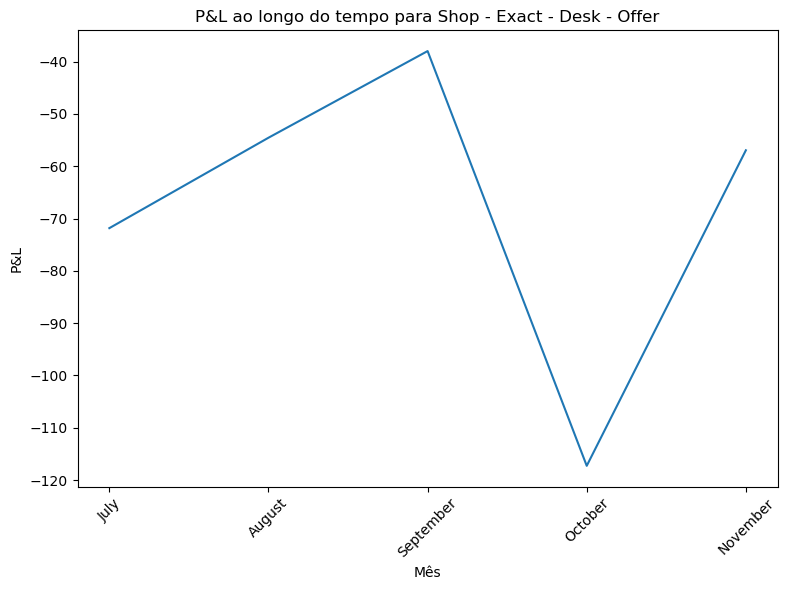

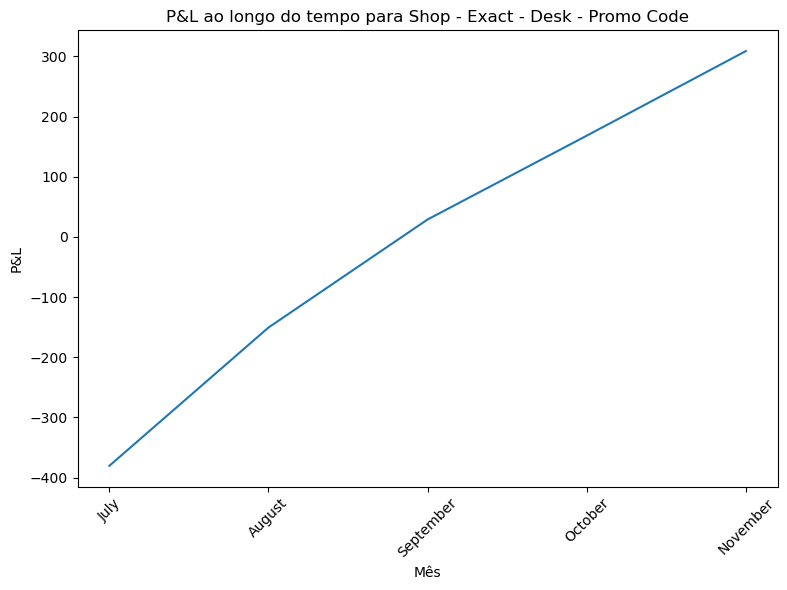

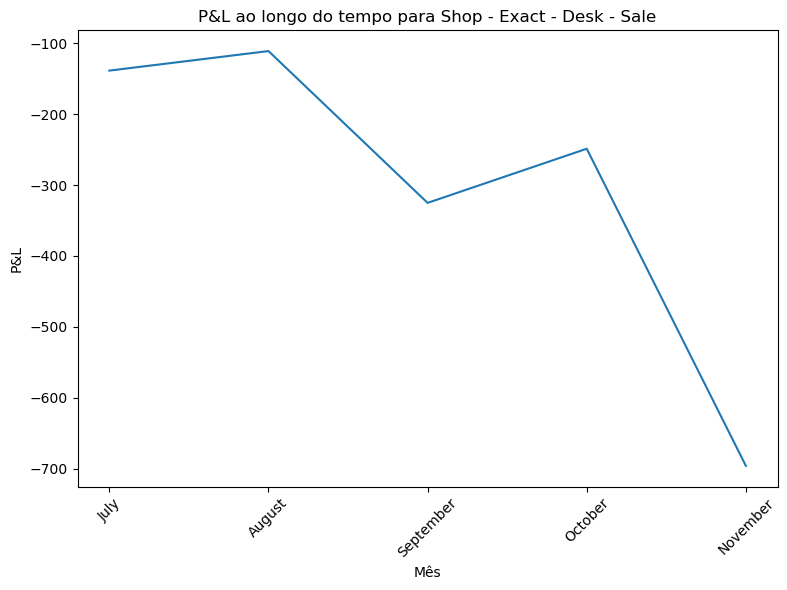

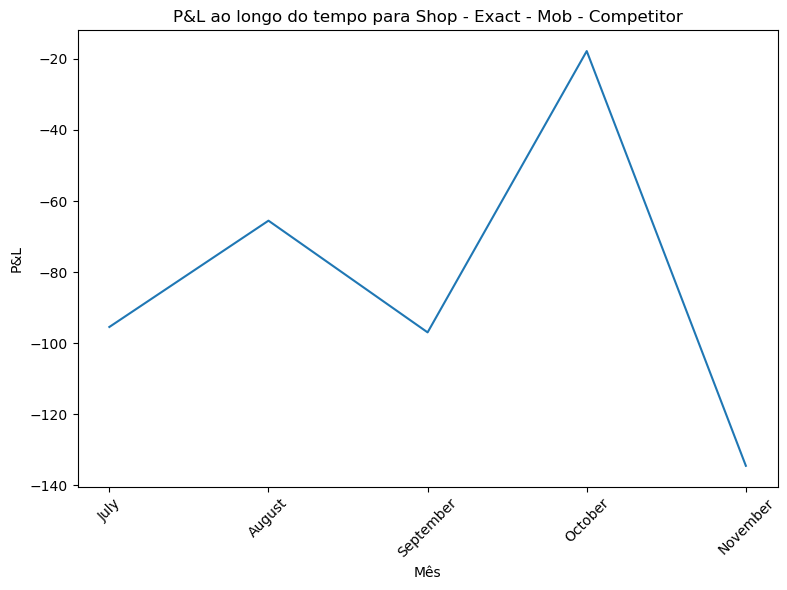

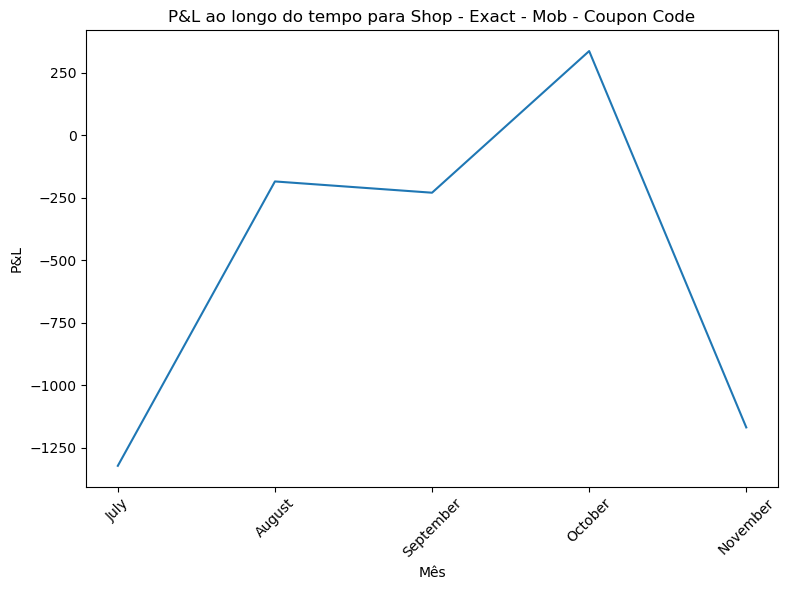

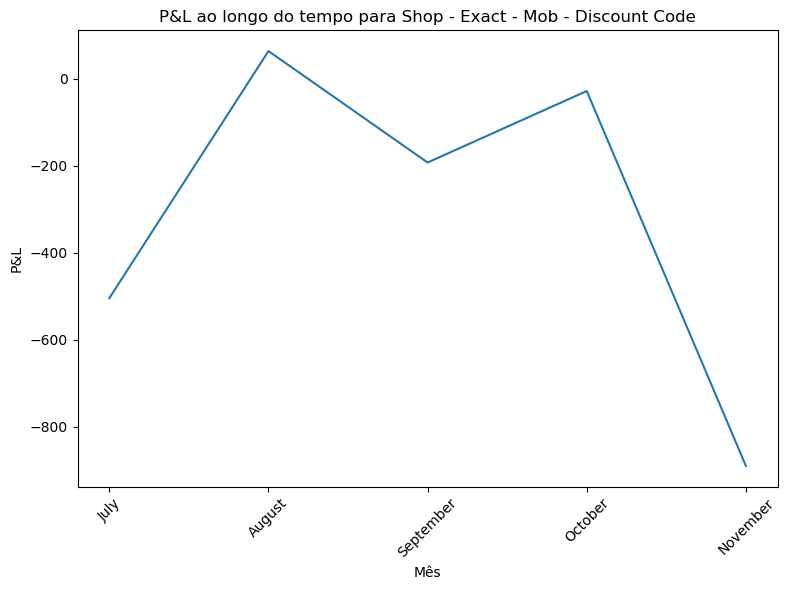

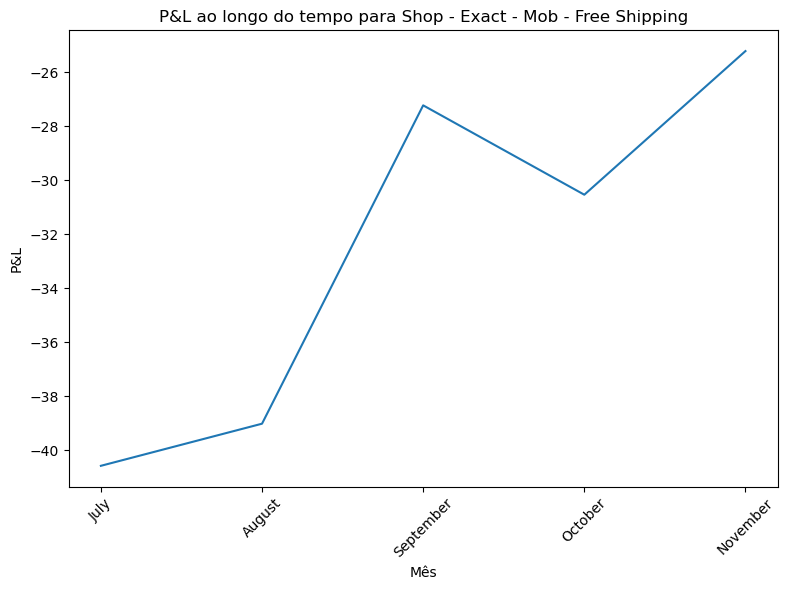

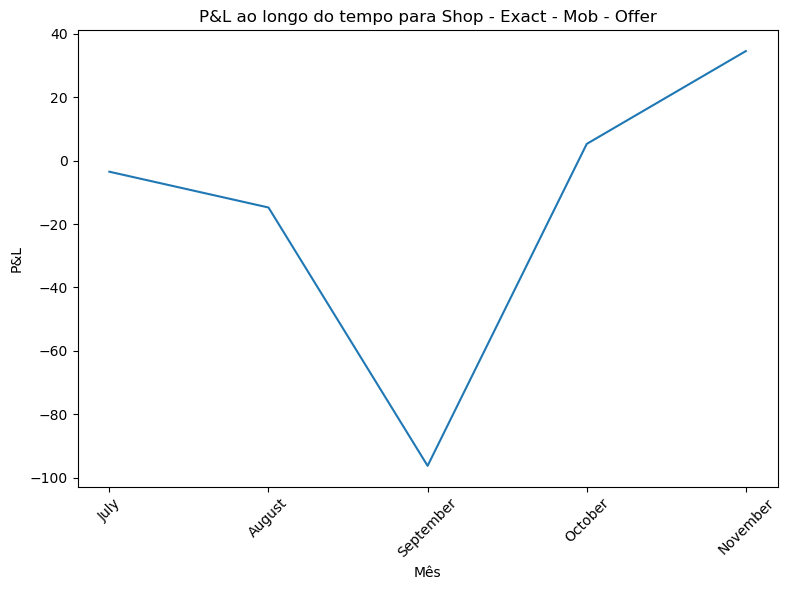

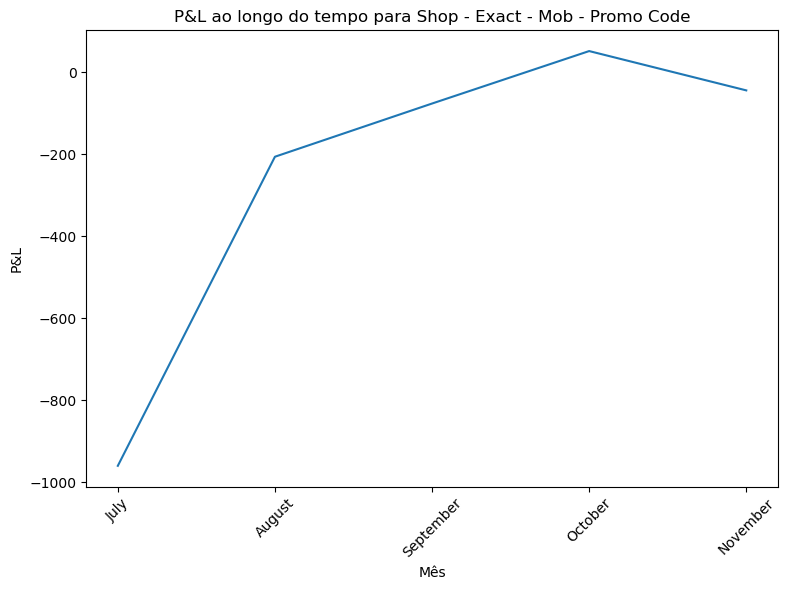

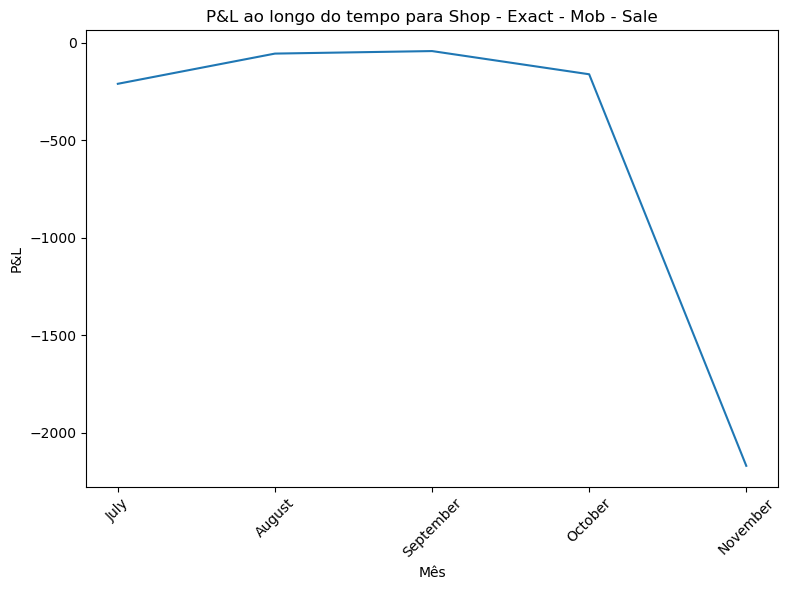

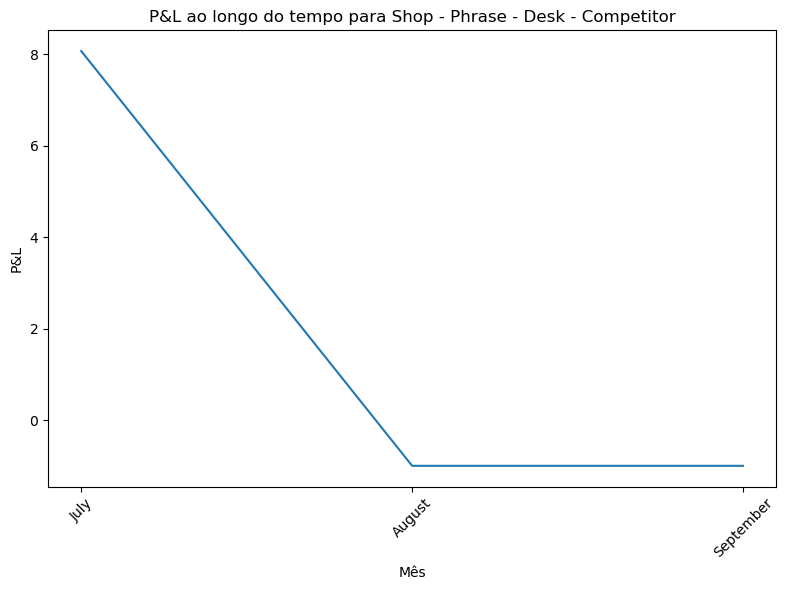

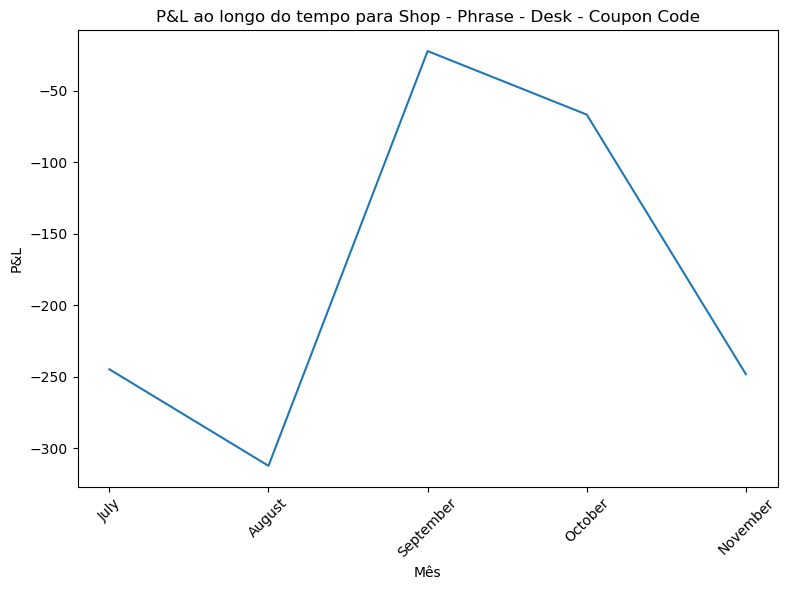

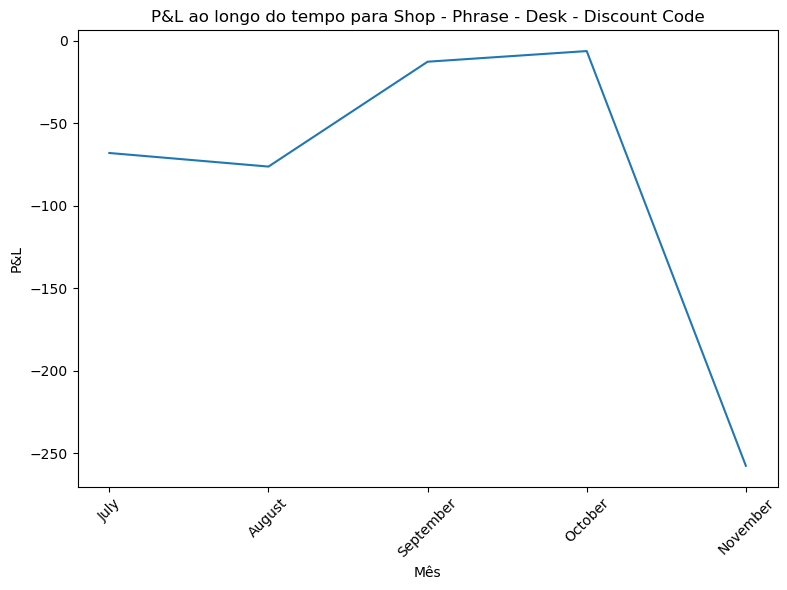

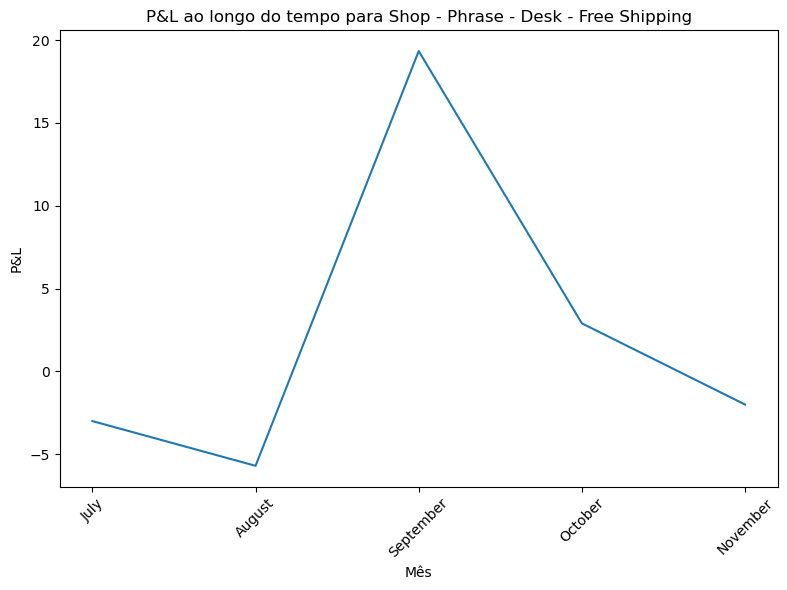

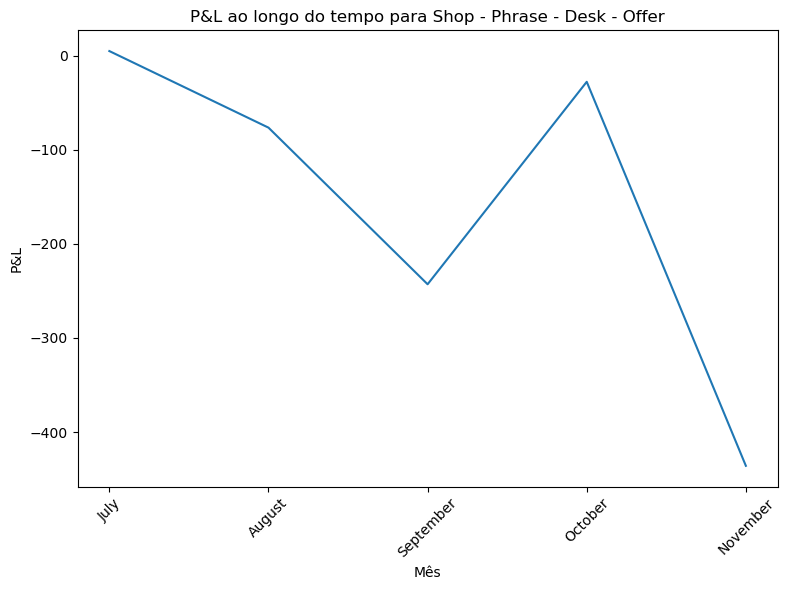

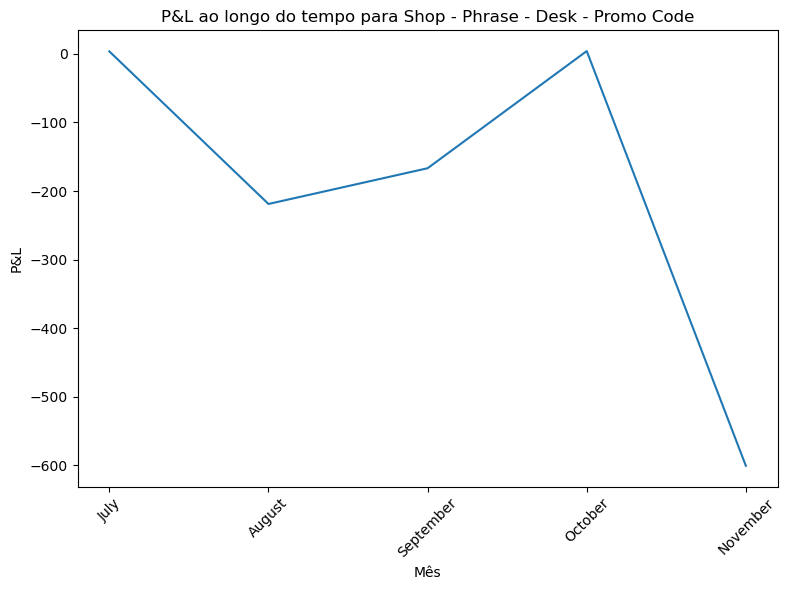

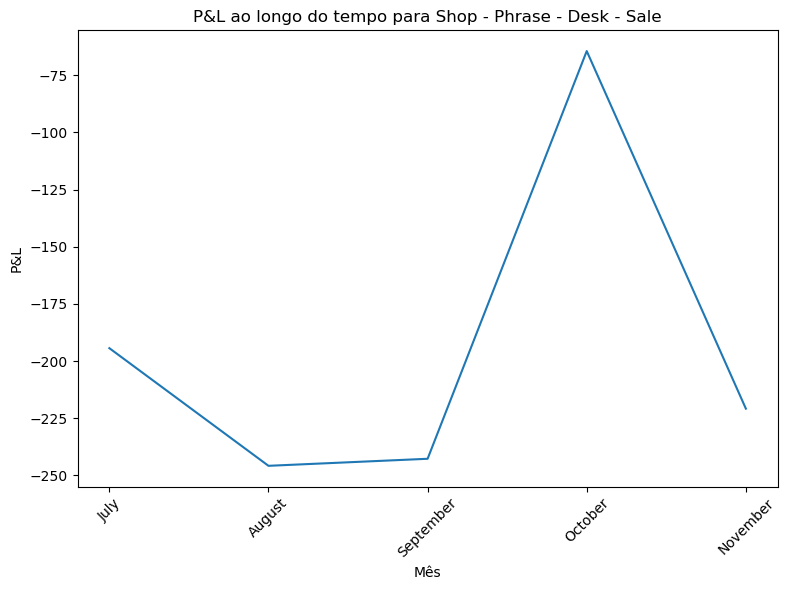

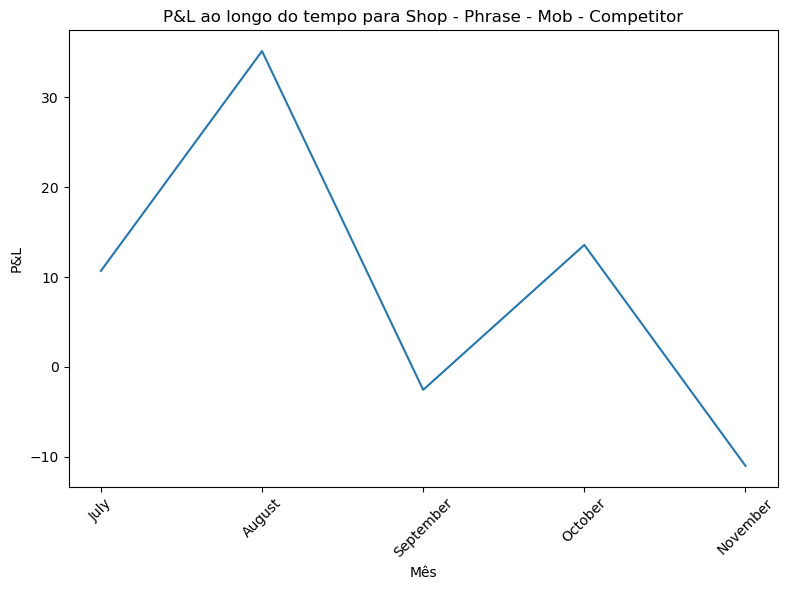

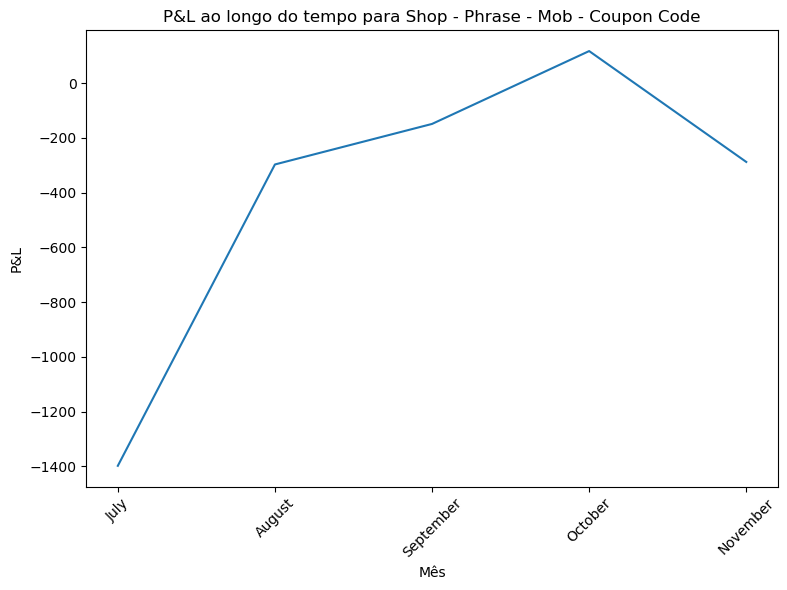

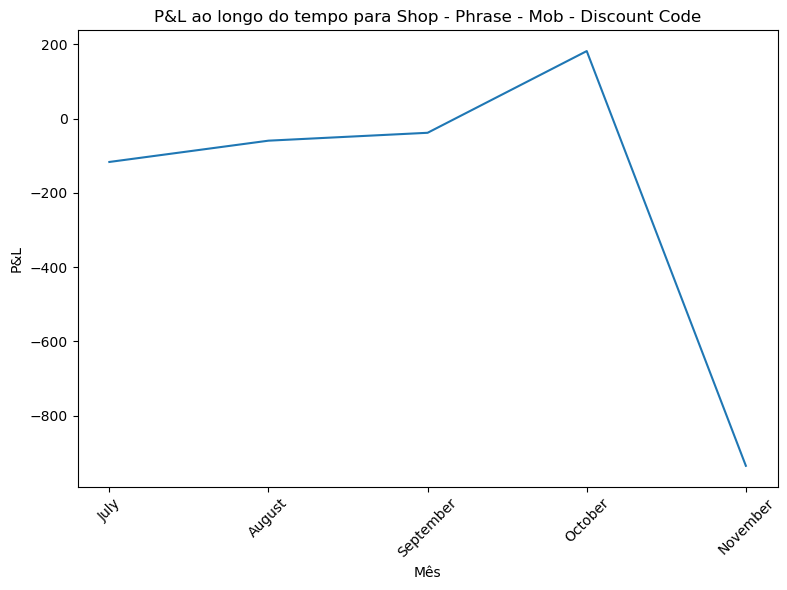

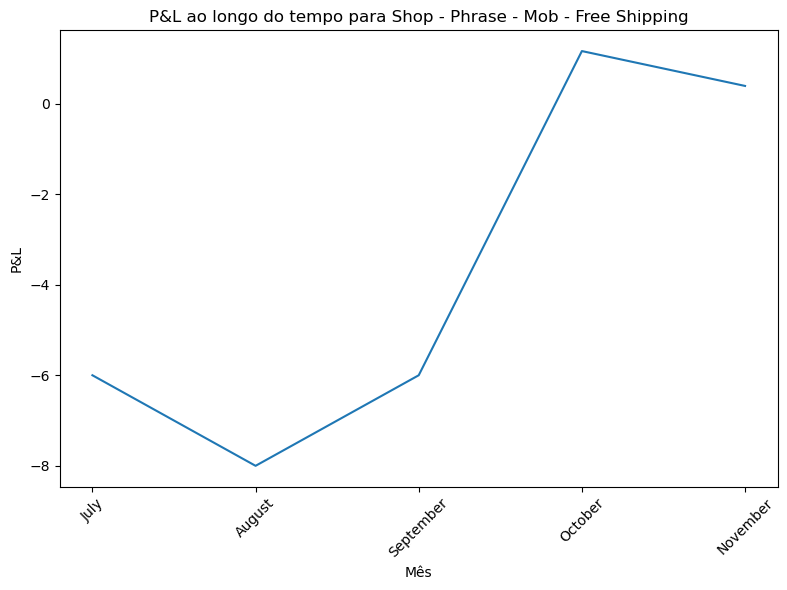

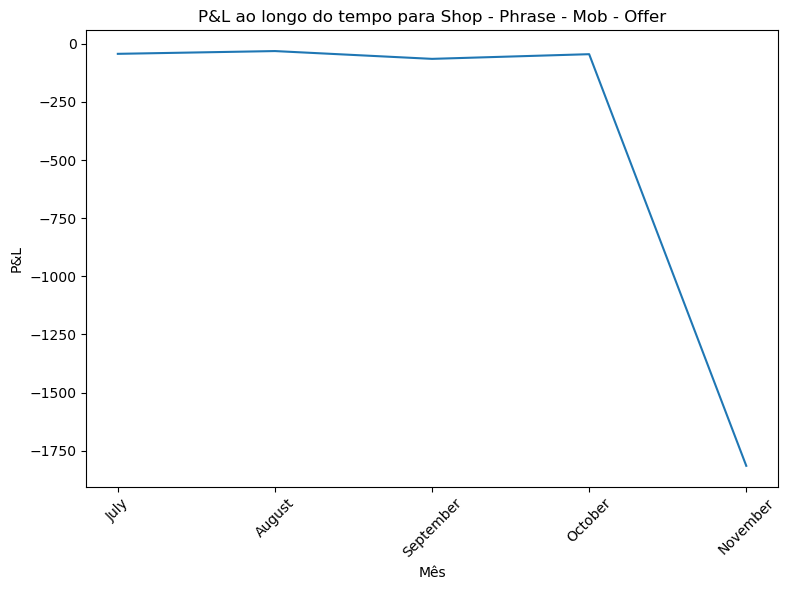

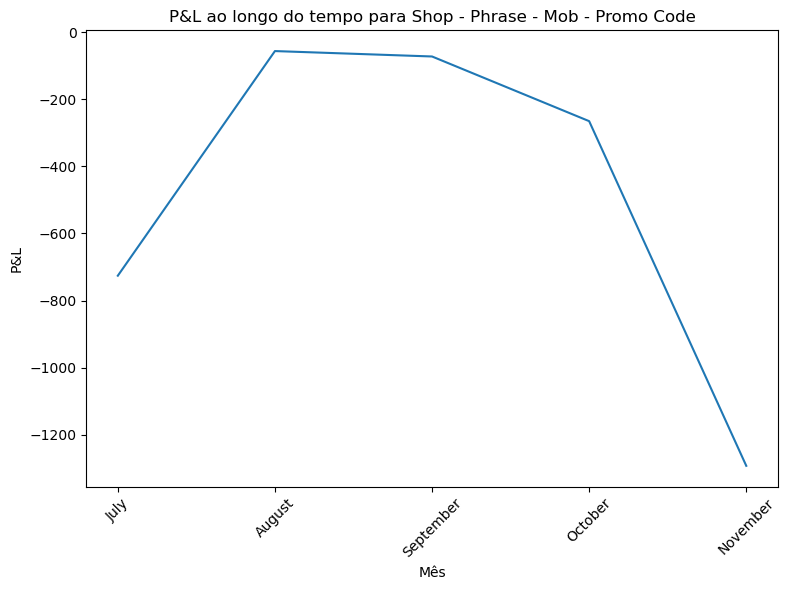

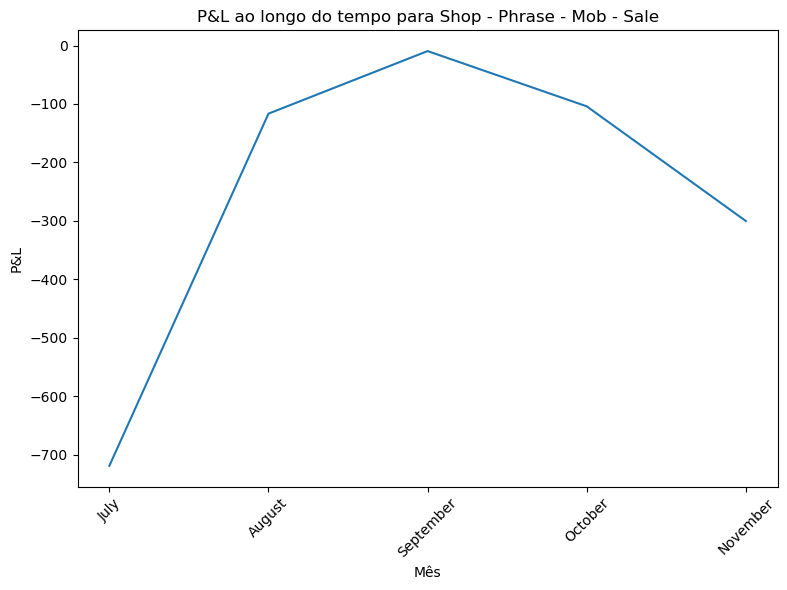

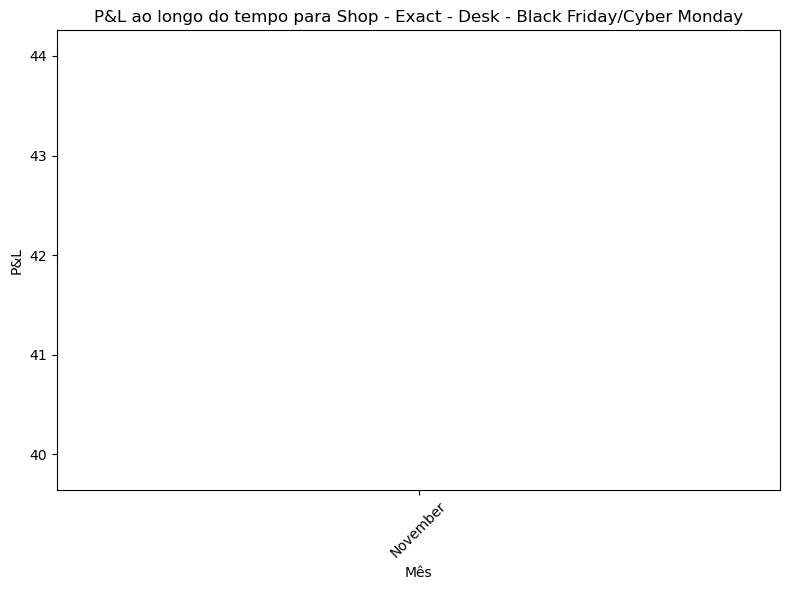

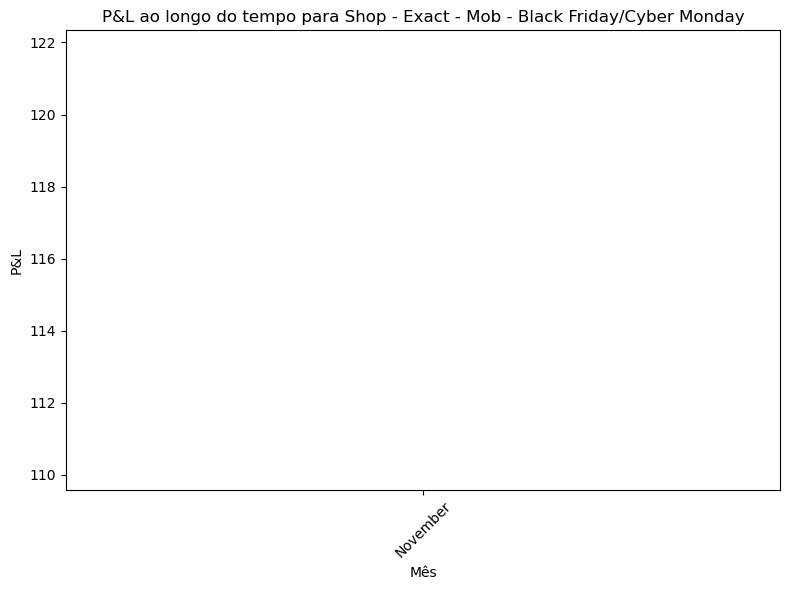

In [20]:
for ad_group in df['Ad Group'].unique():
    df_ad_group = df[df['Ad Group'] == ad_group]
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=df_ad_group, x='Month', y='P&L')
    plt.title(f'P&L ao longo do tempo para {ad_group}')
    plt.xlabel('Mês')
    plt.ylabel('P&L')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

O que pude perceber avaliando o P&L de cada Ad Group no tempo:
- Tivemos uma campanha sazonal (Black Friday/Cyber Monday)
- Muitas campanhas performaram bem em outubro. Hipótese: Provavelmente o público estava movido pela antecipação da Black Friday
- Quase todas as campanhas tiveram uma queda expressiva em novembro. Hipótese: Acredito que houve uma falta de comunicação e falta de percepção de comportamento de público. Podem ter dedicado mais investimento aos anúncios antigos e esperado uma movimentação orgânica do público que buscava ofertas de Black Friday

### Cost x P&L

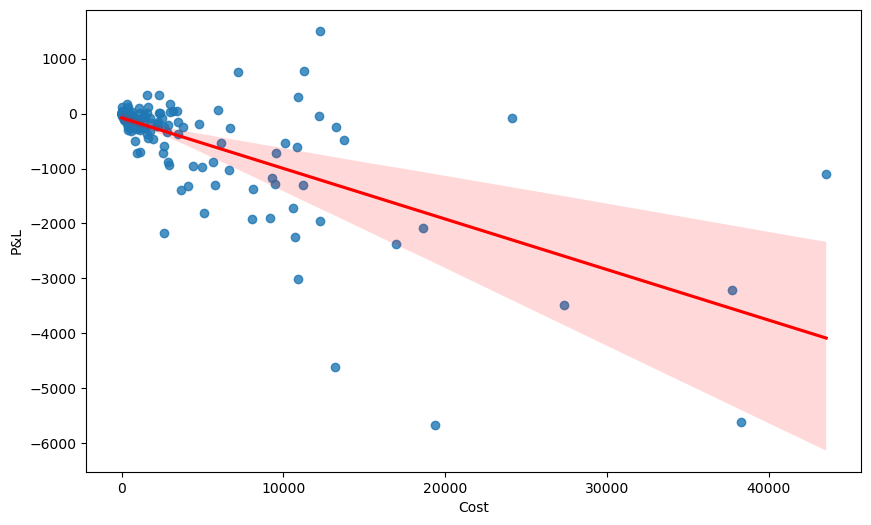

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Cost', y='P&L', line_kws={'color': 'red'});

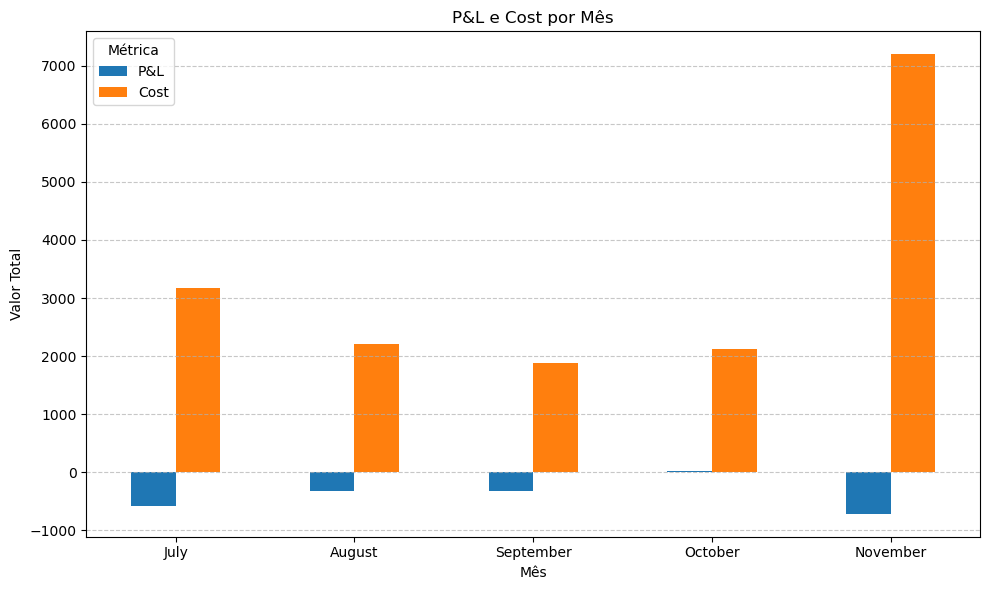

In [22]:
pl_cost = df.groupby('Month').agg({'P&L': 'mean', 'Cost': 'mean'}).reset_index()

pl_cost['Month'] = pl_cost['Month'].astype(str)
pl_cost.plot(x='Month', y=['P&L', 'Cost'], kind='bar', figsize=(10, 6))
plt.xticks(rotation=0)
plt.title('P&L e Cost por Mês')
plt.xlabel('Mês')
plt.ylabel('Valor Total')
plt.legend(title='Métrica')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#### Distribuição do P&L e Cost

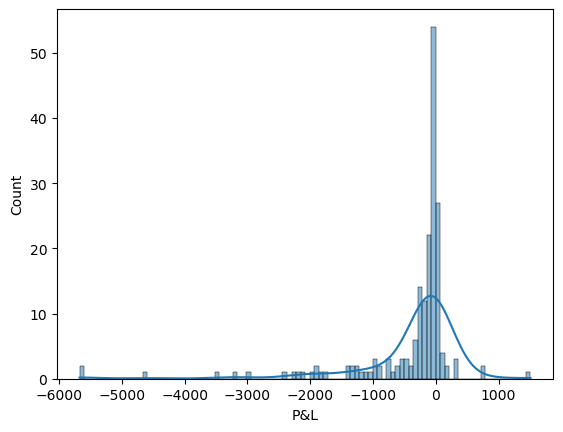

In [23]:
sns.histplot(data=df, x='P&L', bins=100, kde=True);

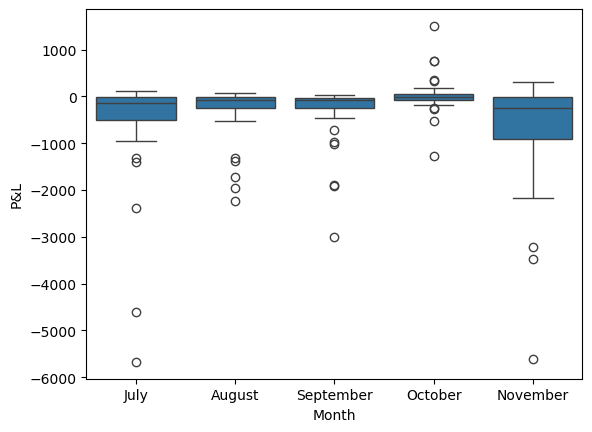

In [24]:
sns.boxplot(data=df, x='Month', y='P&L');

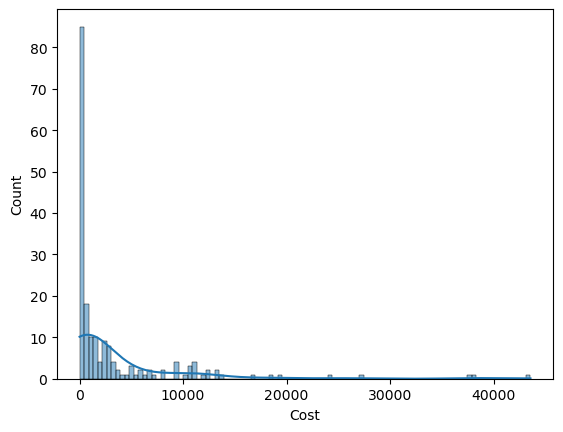

In [25]:
sns.histplot(data=df, x='Cost', bins=100, kde=True);

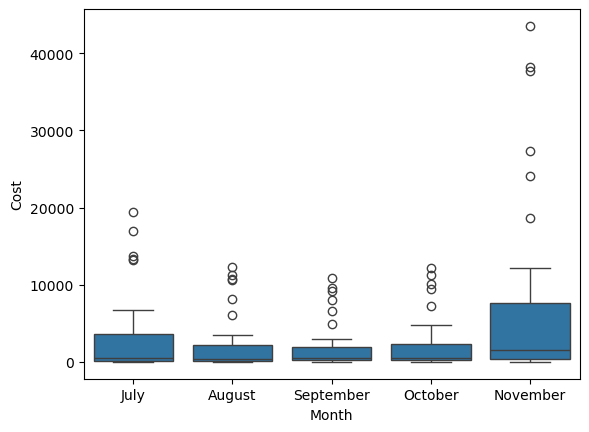

In [26]:
sns.boxplot(data=df, x='Month', y='Cost');

## Análise de correlações

In [27]:
metricas = ['roas', 'ticket', 'Revenue', 'P&L','cpa','revenue_vs_cpa','Cost','CTR','taxa_conversao', 'CPC','conv_imp', 'Sale Amount','roi']

- Vale lembrar que Black Friday/Cyber Monday é uma campanha sazonal, então é esperado que ela tenha um ROAS mais alto, pois as pessoas estão mais propensas a comprar durante esse período.

In [28]:
df.groupby('Ad Group')[metricas].mean().round(2).sort_values(by='roas', ascending=False).reset_index().head()

,Ad Group,roas,ticket,Revenue,P&L,cpa,revenue_vs_cpa,Cost,CTR,taxa_conversao,CPC,conv_imp,Sale Amount,roi
0,Shop - Exact - Desk - Black Friday/Cyber Monday,15.00,128.40,45.0,41.95,0.43,6.00,3.0,0.09,0.29,0.14,0.03,898.80,1400.00
1,Shop - Phrase - Desk - Free Shipping,4.32,168.39,5.6,2.31,2.40,3.20,3.4,0.11,0.10,0.52,0.01,168.39,332.00
2,Shop - Exact - Mob - Black Friday/Cyber Monday,3.64,136.19,160.0,115.96,1.83,4.83,44.0,0.07,0.09,0.17,0.01,3268.63,263.64
3,Shop - Phrase - Mob - Competitor,2.68,149.10,17.4,9.17,4.30,3.13,8.2,0.23,0.15,0.55,0.04,347.25,168.44
4,Shop - Exact - Desk - Free Shipping,1.00,79.29,69.2,-3.07,2.76,0.08,72.4,0.23,0.15,0.41,0.03,1792.12,0.05


- Free Shipping tem baixo custo de investimento, mas lidera em ticket e dentre as campanhas agrupadas, é a única com P&L positivo. A hipótese é que o anúncio serve apenas para acelerar o processo de decisão de compra. Aumentar budget aqui não necessariamente escalaria os resultados.

In [29]:
df.groupby('Ad Group')[metricas].mean().round(2).sort_values(by='ticket', ascending=False).reset_index().head()

,Ad Group,roas,ticket,Revenue,P&L,cpa,revenue_vs_cpa,Cost,CTR,taxa_conversao,CPC,conv_imp,Sale Amount,roi
0,Shop - Phrase - Desk - Free Shipping,4.32,168.39,5.6,2.31,2.40,3.20,3.4,0.11,0.10,0.52,0.01,168.39,332.00
1,Shop - Exact - Desk - Discount Code,0.86,159.57,582.6,-110.24,8.09,-1.21,692.8,0.23,0.14,1.09,0.03,13269.77,-14.36
2,Shop - Exact - Mob - Offer,0.91,159.33,296.8,-14.95,8.52,-1.01,311.8,0.25,0.08,0.68,0.02,6260.49,-8.67
3,Shop - Phrase - Desk - Discount Code,0.73,157.75,260.6,-84.20,9.59,-2.74,344.8,0.16,0.11,1.04,0.02,6064.01,-26.65
4,Shop - Exact - Desk - Promo Code,0.99,154.41,4764.2,-4.87,6.88,-0.08,4769.2,0.34,0.21,1.43,0.07,105288.53,-1.19


- Revenue se mostra como uma métrica que pouco contribui para a avaliação de uma boa performance, visto que as campanhas com melhor Revenue não obtiveram lucro

In [30]:
df.groupby('Ad Group')[metricas].mean().round(2).sort_values(by='Revenue', ascending=False).reset_index().head()

,Ad Group,roas,ticket,Revenue,P&L,cpa,revenue_vs_cpa,Cost,CTR,taxa_conversao,CPC,conv_imp,Sale Amount,roi
0,Shop - 1:1 - Mob - [shop promo code],0.93,117.75,17634.2,-1079.75,5.84,-0.42,18714.0,0.44,0.12,0.69,0.05,377361.62,-6.66
1,Shop - 1:1 - Mob - [shop coupon],0.84,116.46,15295.0,-3004.58,6.67,-1.21,18299.4,0.38,0.05,0.33,0.02,322708.02,-16.03
2,Shop - 1:1 - Desk - [shop promo code],0.90,130.23,14861.0,-1436.20,6.67,-0.67,16297.0,0.39,0.22,1.47,0.09,319199.22,-9.57
3,Shop - 1:1 - Desk - [shop coupon],0.86,125.55,12063.4,-1776.00,6.89,-0.99,13839.6,0.37,0.15,1.03,0.06,255468.90,-13.96
4,Shop - 1:1 - Mob - [shop coupon code],0.89,120.65,10589.2,-1265.09,6.50,-0.90,11854.4,0.44,0.09,0.58,0.04,225151.49,-11.42


- Mês com P&L positivo: Outubro
- Mês com roi positivo: Novembro

In [31]:
df.groupby('Month')[['Revenue', 'Cost', 'P&L','roi']].mean().reset_index()

,Month,Revenue,Cost,P&L,roi
0,July,2595.131579,3172.131579,-576.916842,-18.572368
1,August,1897.789474,2216.447368,-318.604474,-10.081316
2,September,1555.078947,1884.131579,-329.038947,25.022895
3,October,2143.324324,2115.027027,28.275135,-0.868378
4,November,6482.897436,7198.794872,-715.939744,20.051538


## Quais campanhas geraram *menor e maior* P&L

### Por P&L único:

In [32]:
# A campanha com maior prejuízo foi "Shop - 1:1 - Mob - [shop coupon]" no mês de Julho.
df[df['P&L'] == df['P&L'].min()]

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Cost,CPC,Revenue,Sale Amount,P&L,device_type,intent,match_type,cpa,roas,ticket,roi,taxa_conversao,revenue_vs_cpa,conv_imp
6,Shop - 1:1 - Mob - [shop coupon],July,152394,59177,0.39,2666,19371,0.33,13699,294536.92,-5672.27,Mobile,shop coupon,1:1,7.27,0.71,110.48,-29.28,0.05,-2.13,0.02


In [33]:
# A campanha com maior lucro foi "Shop - 1:1 - Mob - [shop coupon]" no mês de Outubro.
df[df['P&L'] == df['P&L'].max()]

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Cost,CPC,Revenue,Sale Amount,P&L,device_type,intent,match_type,cpa,roas,ticket,roi,taxa_conversao,revenue_vs_cpa,conv_imp
114,Shop - 1:1 - Mob - [shop coupon],October,93406,36068,0.39,2444,12236,0.34,13744,285638.3,1507.68,Mobile,shop coupon,1:1,5.01,1.12,116.87,12.32,0.07,0.62,0.03


### Por P&L médio

In [34]:
menor_p_l = df.groupby(['Ad Group'])['P&L'].mean().sort_values(ascending=True).head()
print(f'Campanhas com menor lucro:\n{menor_p_l}')

Campanhas com menor lucro:
Ad Group
Shop - 1:1 - Mob - [shop coupon]        -3004.576
Shop - 1:1 - Desk - [shop coupon]       -1776.002
Shop - 1:1 - Desk - [shop promo code]   -1436.196
Shop - 1:1 - Mob - [shop coupon code]   -1265.086
Shop - 1:1 - Mob - [shop promo code]    -1079.754
Name: P&L, dtype: float64


In [35]:
maior_p_l = df.groupby(['Ad Group'])['P&L'].mean().sort_values(ascending=False).head()
print(f'Campanhas com maior lucro:\n{maior_p_l}')

Campanhas com maior lucro:
Ad Group
Shop - Exact - Mob - Black Friday/Cyber Monday     115.960000
Shop - Exact - Desk - Black Friday/Cyber Monday     41.950000
Shop - Phrase - Mob - Competitor                     9.166000
Shop - Phrase - Desk - Free Shipping                 2.308000
Shop - Phrase - Desk - Competitor                    2.023333
Name: P&L, dtype: float64


## Analisando hipótese para queda de performance em Novembro

Pude verificar que no mês de novembro, período de Black Friday, as campanhas tiveram uma abrupta queda de performance. A partir das análises, inferi que isso pode ter acontecido por falta de percepção de comportamento do público.

- 1: Em novembro, o público está aquecido, na expectativa das ofertas de Black Fridar, porém é possível ver que foram feitos investimentos altos nas campanhas comuns, mas investimento insuficente em campanhas voltadas para Black Friday. Talvez, houvesse a expectativa por uma busca orgânica.
- 2: O interesse existia no público, conforme podemos analisar pelos valores de P&L (positivo), CPC (baixo) e roi (altíssimo)
- 3: Acredito que não houve monitoramento da campanha para perceber a oportunidade

In [36]:
df[df["Month"] == 'November'][['Ad Group', 'Revenue', 'Cost', 'P&L', 'CPC', 'roi']].sort_values(by='Cost', ascending=False)

,Ad Group,Revenue,Cost,P&L,CPC,roi
159,Shop - 1:1 - Mob - [shop promo code],42440,43542,-1101.90,0.76,-2.53
151,Shop - 1:1 - Mob - [shop coupon],32668,38273,-5605.30,0.38,-14.64
153,Shop - 1:1 - Desk - [shop promo code],34518,37729,-3211.12,1.60,-8.51
152,Shop - 1:1 - Desk - [shop coupon],23857,27336,-3478.64,1.08,-12.73
175,Shop - 1:1 - Mob - [shop coupon code],24071,24149,-77.73,0.57,-0.32
155,Shop - 1:1 - Desk - [shop coupon code],16555,18641,-2086.30,1.30,-11.19
177,Shop - Exact - Mob - Promo Code,12145,12189,-44.19,0.64,-0.36
189,Shop - Exact - Desk - Promo Code,11223,10914,308.98,1.41,2.83
164,Shop - Phrase - Desk - Promo Code,10223,10823,-600.46,1.31,-5.54
158,Shop - Exact - Mob - Coupon Code,8134,9302,-1168.01,0.49,-12.56


## Taxa de Conversão e CPC por Dispositivo

In [37]:
device_tc_cpc = df.groupby('device_type').agg({'taxa_conversao': 'mean', 'CPC': 'mean'}).reset_index()
print(device_tc_cpc)

  device_type  taxa_conversao       CPC
0        Desk        0.152660  1.080319
1      Mobile        0.074167  0.508229


In [38]:
device_impresions_clicks = df.groupby('device_type').agg({'Impressions': 'sum', 'Clicks': 'sum'}).reset_index()
print(device_impresions_clicks)

  device_type  Impressions  Clicks
0        Desk       757893  234939
1      Mobile      1916806  689564


- Convencionalmente, o CPC no Mobile tende a ser menor porque há mais espaços para anúncios. No Desk, o CPC tende a ser mais alto, pois há um público mais qualificado, e por isso, mais concorrido.
- A taxa de conversão indica onde estão as reais intenções de compra. O mobile gera o dobro de cliques pagando metade do preço, mas converte pouco.
- O mobile investe mais dinheiro em cliques que não convertem, enquanto o desktop entrega conversões mais qualificadas apesar do CPC maior.

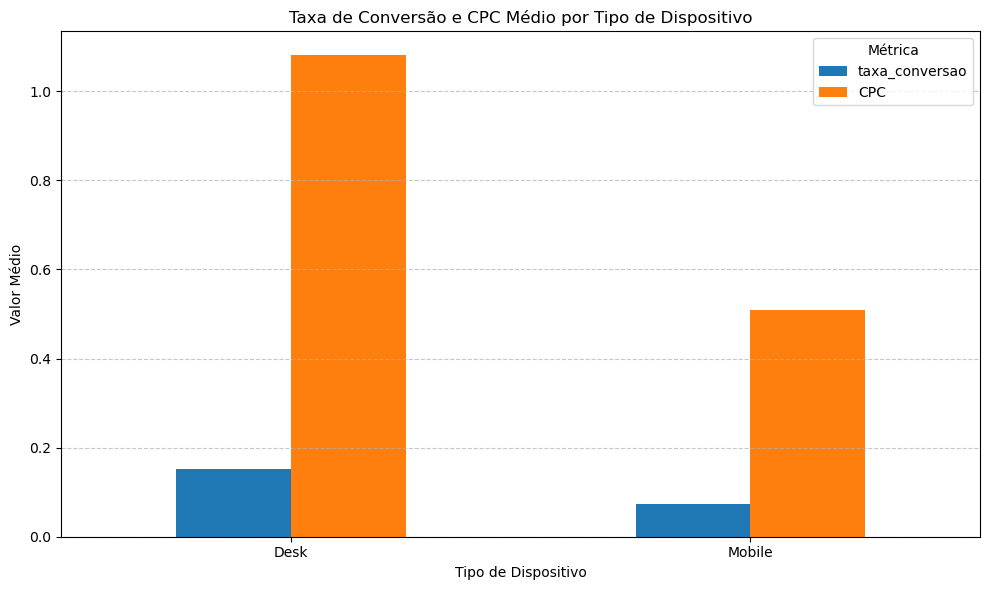

In [39]:
device_tc_cpc.plot(x='device_type', y=['taxa_conversao', 'CPC'], kind='bar', figsize=(10, 6))
plt.title('Taxa de Conversão e CPC Médio por Tipo de Dispositivo')
plt.xlabel('Tipo de Dispositivo')
plt.ylabel('Valor Médio')
plt.xticks(rotation=0)
plt.legend(title='Métrica')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


# Definindo as melhores campanhas com Clustering (KMeans)

Foi aplicado o algoritmo KMeans com 4 clusters para segmentar as campanhas por perfil de performance, sem definição manual de pesos ou critérios. As features utilizadas foram padronizadas com StandardScaler para garantir que nenhuma variável dominasse o agrupamento por diferença de escala.
Features utilizadas:

roas → eficiência financeira
taxa_conversao → qualidade pós-clique
conv_imp → qualidade do público
CPC → custo por clique
cpa → custo por aquisição
revenue_vs_cpa → ganhou ou perdeu na aquisição da conversão
roi → retorno sobre investimento

Resultado:

Cluster 0 → Críticas: ROI de -63%, público errado, corte imediato
Cluster 1 → Viáveis: único cluster lucrativo no modelo atual
Cluster 2 → Operando no limite: volume sem qualidade, revisão necessária
Cluster 3 → Excelentes: Black Friday, ROI de 1650%, subinvestida

In [40]:
conda update scikit-learn scipy numpy

Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
print(KMeans)

<class 'sklearn.cluster._kmeans.KMeans'>


In [105]:
features = ['roas', 'taxa_conversao', 'conv_imp', 'CPC', 'cpa', 'revenue_vs_cpa', 'roi']
X = df[features]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [111]:
print(df.groupby('cluster')[features].mean().applymap(lambda x: '%.2f' % x))

          roas taxa_conversao conv_imp   CPC    cpa revenue_vs_cpa      roi
cluster                                                                    
0         0.37           0.04     0.00  0.62  17.79         -12.11   -63.15
1         1.06           0.19     0.06  1.26   7.00          -0.36     6.18
2         0.82           0.08     0.02  0.56   6.65          -1.26   -18.51
3        17.50           0.27     0.03  0.29   0.71          12.50  1650.00


In [112]:
clusters = df['cluster'].unique().tolist()
print(f'Clusters identificados: {clusters}')

Clusters identificados: [1, 2, 0, 3]


In [115]:
print(f'Cluster com as melhores campnhas: {clusters[3]}')
print(f'Cluster com campanhas intermediárias: {clusters[0]}')
print(f'Cluster com campanhas operando no limite: {clusters[1]}')
print(f'Cluster com campanhas críticas: {clusters[2]}')

Cluster com as melhores campnhas: 3
Cluster com campanhas intermediárias: 1
Cluster com campanhas operando no limite: 2
Cluster com campanhas críticas: 0


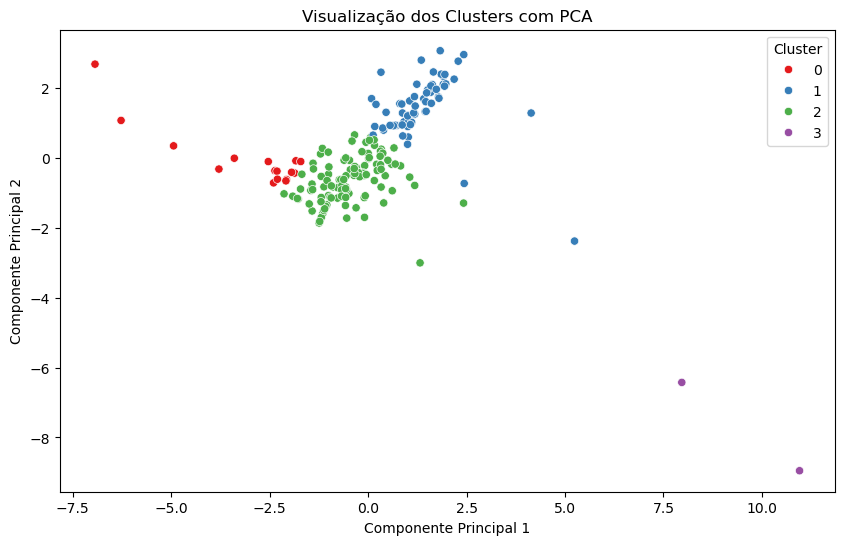

In [116]:
# Visualização dos clusters usando PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='Set1')
plt.title('Visualização dos Clusters com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

In [117]:
# Transformando os clusters em categorias para facilitar a interpretação e visualização dos dados.
cluster_mapping = {
    3: 'Melhores Campanhas',
    1: 'Campanhas Intermediárias',
    2: 'Operando no Limite',
    0: 'Campanhas Críticas'
}
df['cluster_category'] = df['cluster'].map(cluster_mapping)
print(df[['Ad Group', 'cluster', 'cluster_category']].head())

                                   Ad Group  cluster          cluster_category
0    Shop - 1:1 - Desk - [shop coupon code]        1  Campanhas Intermediárias
1         Shop - 1:1 - Desk - [shop coupon]        1  Campanhas Intermediárias
2  Shop - 1:1 - Desk - [shop discount code]        1  Campanhas Intermediárias
3     Shop - 1:1 - Desk - [shop promo code]        1  Campanhas Intermediárias
4          Shop - 1:1 - Desk - [shop promo]        1  Campanhas Intermediárias


#### Campanhas críticas:

In [121]:
df[df['cluster'] == clusters[2]][['Ad Group', 'P&L', 'roas', 'taxa_conversao', 'conv_imp', 'CPC', 'cpa', 'revenue_vs_cpa']].sort_values(by='P&L', ascending=False)

,Ad Group,P&L,roas,taxa_conversao,conv_imp,CPC,cpa,revenue_vs_cpa
35,Shop - Phrase - Mob - Offer,-43.57,0.15,0.03,0.01,0.49,17.33,-14.67
68,Shop - Phrase - Mob - Discount Code,-59.70,0.46,0.04,0.01,0.48,12.33,-6.67
105,Shop - Exact - Mob - Competitor,-96.95,0.41,0.04,0.01,0.45,11.71,-6.93
61,Shop - Exact - Desk - Sale,-110.75,0.59,0.06,0.01,0.80,13.65,-5.55
33,Shop - Phrase - Mob - Discount Code,-117.02,0.15,0.02,0.00,0.53,34.50,-29.25
30,Shop - Phrase - Desk - Sale,-194.38,0.54,0.06,0.00,0.72,12.53,-5.71
171,Shop - Phrase - Desk - Sale,-220.84,0.43,0.04,0.00,0.58,12.87,-7.37
96,Shop - Phrase - Desk - Sale,-242.78,0.39,0.05,0.00,0.76,15.38,-9.35
55,Shop - Phrase - Desk - Sale,-245.86,0.49,0.06,0.01,0.77,13.14,-6.65
132,Shop - Exact - Desk - Sale,-248.60,0.44,0.05,0.01,0.59,12.08,-6.73


# Insights finais

## A comissão atual é justa?

Hipotése: Hoje as campanha operam sob um comissão de 4,6% sobre o Sale Amount, talvez uma renegociação da porcentagem da comissão ajudasse o negócio a ser mais lucrativo. Dividindo o custo total / total vendido chegamos a qual percentual do que a loja vendeu precisa ser repassado para cobrir o custo dos anúncios.

In [130]:
venda_por_dolar = df['Sale Amount'].sum() / df['Cost'].sum()
print((venda_por_dolar).round(2))

18.96


In [131]:
recebido_por_dolar = df['Revenue'].sum() / df['Cost'].sum()
print((recebido_por_dolar).round(2))

0.88


In [132]:
comissão_mínima_viável = df['Cost'].sum() / df['Sale Amount'].sum()
print(f'Comissão mínima viável: {comissão_mínima_viável:.2%}')

Comissão mínima viável: 5.27%


1. O modelo não está funcionando
A maior parte das campanhas opera no prejuízo. A comissão de 4,6% é pequena demais.

2. Apenas o Cluster 1 é viável no modelo atual
roi de 6,18% e roas de 1,06. Mesmo assim o revenue_vs_cpa de -0,36 mostra que está no limite, perdendo R$ 0,36 por conversão. Qualquer variação pode levar uma campanha ao prejuízo.

3. O Cluster 0 deve ser cortado imediatamente
roi de -63,15% e revenue_vs_cpa de -12,11, perde 12,11 em cada conversão. cpa de 17,79 com conv_imp zerado confirma que o anúncio está aparecendo para o público completamente errado. O budget dessas campanhas realocado para o Cluster 1 mudaria o resultado geral.

4. O Cluster 2 é o maior dreno de budget
Provavelmente as campanhas mobile, como vimos anteriormente, elas possuem CPC baixo de 0,56 mas a taxa_conersao é de de apenas 8% e ainda, um roi de -18,51%.

5. A Black Friday é um caso isolado e que foi uma oportunidade perdida
Gerou números que não foram superados por nenhuma outra campanha. Se tivessem investido o suficiente, o resultado teria sido completamente diferente.

6. Desktop e mobile se separam naturalmente
Para um modelo de margem apertada de 4,6%, desktop é mais eficiente apesar do CPC maior.

7. Outubro foi o único mês lucrativo por razões estruturais
CPC ainda não tinha subido pela competição da Black Friday e o consumidor ainda comprava normalmente. O Cluster 1 performou melhor nesse mês, confirmando que o modelo só funciona quando o CPC está controlado.

8. Free Shipping opera numa lógica diferente
Keyword de fundo de funil com usuário já decidido a comprar. Não precisa ser escalada, só aparecer no momento certo para o cliente.